# Purpose 
 
The present verification report aims at checking the post-processing of the convective, diffusive and source terms of the standard and realisable $k$-$\varepsilon$ and the standard $k$-$\omega$ transport equations using VDF and VEF discretizations. No numerical resolution is performed. The SST model is cannot be verified as it requires a wall boundary condition to compute a wall distance in the blending function.

Validation made by: Pierre-Emmanuel Angeli and Alan Burlot

# Problem Description 

## Geometry 

The computational domain is the unit cube.

## Initial Conditions and Boundary Conditions 

- **Boundary conditions**: Triple periodicity.


- **Initial conditions**: Periodic velocity, turbulent kinetic energy and turbulent dissipation fields defined by the following analytical expressions:

\begin{align*}
&\text{velocity vector: } && \textbf{u}(x,y,z) = \begin{pmatrix} -2 \cos(2\pi x) \sin(2\pi y) \sin(2\pi z) \\\\ \sin(2\pi x) \cos(2\pi y) \sin(2\pi z) \\\\ \sin(2\pi x) \sin(2\pi y) \cos(2\pi z) \end{pmatrix} \\ 
&\text{turbulent kinetic energy: } && k(x,y,z) = \cos(2 \pi y)+2 \\ 
&\text{turbulent dissipation rate: } && \varepsilon(x,y,z) = \sin(2 \pi y)+2 \\
&\text{turbulence specific dissipation rate: } && \omega(x, y, z) = \sin(2 \pi y)+2\end{align*}

N.B.: The imposed velocity field has a zero divergence.

## Fluid Properties 

- $\mu$ = 0.001 Pa.s
- $\rho$ = 1000 kg/s

## Flow Physics 

This is a verification of post-processing: analytical velocity, $k$ and $\varepsilon$ fields are imposed and frozen (no resolution of the flow).

# Case Setup 

## Grid 

- The VDF mesh has 101 points in each direction $\Rightarrow (101-1)^3 = 10^6$ cells.
- The VEF mesh has 26 points in each direction and the cells are divided into 48 tetrahedra with the ```tetraedriser_homogene_fin``` option $\Rightarrow 48 \times (26-1)^3 = 7.5 \cdot 10^5$ cells.


## Model Options 

The transport equations of $k$ and $\varepsilon$ write under the following form:

\begin{align*}
&\dfrac{\partial k}{\partial t} + \underbrace{U_i \dfrac{\partial k}{\partial x_i}}_{\text{conv}_k} = \underbrace{\dfrac{\partial}{\partial x_i} \left[ \left( \dfrac{\nu_t}{\sigma_k} \right) \dfrac{\partial k}{\partial x_i} \right]}_{\text{diff}_k} + \underbrace{P - \varepsilon}_{\text{ source}_k}\\
&\dfrac{\partial \varepsilon}{\partial t} + \underbrace{U_i \dfrac{\partial \varepsilon}{\partial x_i}}_{\text{conv}_\varepsilon} = \underbrace{\dfrac{\partial}{\partial x_i} \left[ \left( \dfrac{\nu_t}{\sigma_\varepsilon} \right) \dfrac{\partial \varepsilon}{\partial x_i} \right]}_{\text{diff}_\varepsilon} + \text{ source}_\varepsilon
\end{align*}

The $\varepsilon$ source term in the standard and realizable $k$--$\varepsilon$ models is defined as:

\begin{align*}
&\text{standard: } && \text{source}_\varepsilon = \dfrac{\varepsilon}{k} \left( C_{\varepsilon_1} P - C_{\varepsilon_2} \varepsilon \right) \\
&\text{realizable: } && \text{source}_\varepsilon = C_1 S \varepsilon -C_2 \dfrac{\varepsilon^2}{k + \sqrt{\nu \varepsilon}}
\end{align*}

The transport equations of $k$ and $\omega$ are expressed as:
\begin{align*}
&\dfrac{\partial k}{\partial t} + \underbrace{U_i \dfrac{\partial k}{\partial x_i}}_{\text{conv}_k} = \underbrace{\dfrac{\partial}{\partial x_i} \left[ \nu_t \sigma_k \dfrac{\partial k}{\partial x_i} \right]}_{\text{diff}_k} + \underbrace{P - \beta_k k \omega}_{\text{ source}_k}\\
&\dfrac{\partial \omega}{\partial t} + \underbrace{U_i \dfrac{\partial \omega}{\partial x_i}}_{\text{conv}_\omega} = \underbrace{\dfrac{\partial}{\partial x_i} \left[ \nu_t \sigma_\omega \dfrac{\partial \omega}{\partial x_i} \right]}_{\text{diff}_\omega} + \underbrace{\frac{\sigma_{\omega}\omega}{k}P - \beta_{\omega} \omega^2 + \frac{\sigma_d}{\omega}\frac{\partial k}{\partial x_j}\frac{\partial \omega}{\partial x_j}}_{\text{source}_{\omega}}
\end{align*}

For the complete description of the models, refer to equations and (21) and (54) of [1].


The analytical expressions are computing using symbolic computation with sympy.


In order to get rid of interpolation of their values, the terms are plotted by means of probes at their real location, namely:
- at gravity center of cells in VDF;
- at face center of cells in VEF.

## Other Options (calculation) 

The ```equation_non_resolue``` option is used to disable the resolution.


The number of time steps ```nb_pas_dt_max``` is set to zero.


# Analytic $k$-$\varepsilon$ computation

## Tools and definitions

We define a gradient function and a divergence function with sympy. The `create_function` function allows to convert the sympy expression in a callable function by lambdifying it.

In [43]:
import sympy
from sympy import cos, sin, pi
import numpy
import pandas
from trustutils import plot

In [44]:
x, y, z = sympy.symbols('x y z', real=True)


def grad(f):
    """Compute the gradient of a scalar function f with respect to x, y, and z."""
    return [sympy.diff(f, x), sympy.diff(f, y), sympy.diff(f, z)]


def div(f):
    """Compute the divergence of a vector field f."""
    return sympy.diff(f[0], x) + sympy.diff(f[1], y) + sympy.diff(f[2], z)


def create_function(func, dsubsti):
    """Lambdify the sympy expression."""
    lam_func = sympy.lambdify([x, y, z],
                              func.subs(dsubsti),
                              modules=[{'sqrt': numpy.emath.sqrt, "Max": numpy.max}, "numpy"])
    return lam_func


Special functions are defined for tensors. The rotation tensor computation was validated to obtain the correct sign.

In [45]:
def compute_strain_tensor(velocity):
    """Compute 1/2*(du_i/dx_j + du_j/dx_i)."""
    gradv = [grad(velocity[0]),
             grad(velocity[1]),
             grad(velocity[2])]
    strain_ij = pandas.DataFrame((pandas.DataFrame(gradv)
                                  + pandas.DataFrame(gradv).T)/2).values.tolist()
    assert numpy.array(strain_ij).shape == (3, 3)
    assert strain_ij[0][1] == strain_ij[1][0]
    assert strain_ij[0][2] == strain_ij[2][0]
    assert strain_ij[1][2] == strain_ij[2][1]

    return strain_ij

def compute_rotation_tensor(velocity):
    """Compute 1/2*(du_i/dx_j - du_j/dx_i)."""
    gradv = [grad(velocity[0]),
             grad(velocity[1]),
             grad(velocity[2])]
    rota_ij = pandas.DataFrame((pandas.DataFrame(gradv).T
                                - pandas.DataFrame(gradv))/2).values.tolist()
    assert numpy.array(rota_ij).shape == (3, 3)
    assert rota_ij[0][1] == - rota_ij[1][0]
    assert rota_ij[0][2] == - rota_ij[2][0]
    assert rota_ij[1][2] == - rota_ij[2][1]
    for diag in [0, 1, 2]:
        assert rota_ij[diag][diag] == 0

    return rota_ij

def compute_tensor_contraction(tensor_ij):
    """Compute einstein summation of TijTij"""
    return numpy.einsum('ij,ij->', numpy.array(tensor_ij), numpy.array(tensor_ij))


## Commons

In [46]:
def compute_convection(velocity, tkeOReps):
    """Compute U_i x dk/dx_i."""
    return sum([a*b for a, b in zip(velocity, grad(tkeOReps))])


def compute_diffusion(tkeOReps, nut):
    """Compute d/dx_i(nu_t/epsX x dX/dx_i)"""
    return div([nut*sympy.diff(tkeOReps, a) for a in [x, y, z]])

## Definition of the models terms

In [47]:
def compute_production_tke(nut, strain):
    """Compute the production term of the turbulent kinetic energy equation."""
    return 2*nut*strain

def compute_sources_tke(prod, eps):
    """Compute the total source termes for the turbulent kinetic energy of the standard k-epsilon
    equation, i.e. Prod - eps."""
    return prod - eps

def compute_sources_eps_std(kepsstd):
    """Compute the total source termes for the turbulent kinetic energy of the standard k-epsilon
    equation, i.e. eps/tke*(C_eps1*Prod - C_eps2*eps)."""
    return kepsstd["eps"]/kepsstd["tke"] * (kepsstd["ceps1"]*kepsstd["prod_tke"]
                                            - kepsstd["ceps2"]*kepsstd["eps"])

def compute_sources_eps_rea(kepsrea):
    """Compute the total source termes for the turbulent kinetic energy of the standard k-epsilon
    equation, i.e. c1*strain*eps - c2*eps*eps/(tke + sympy.sqrt(nu*eps))."""
    tke, eps = kepsrea["tke"], kepsrea["eps"]
    S = kepsrea["S"]
    c1, c2, nu = kepsrea["c1"], kepsrea["c2"], kepsrea["nu"]
    return c1*S*eps - c2*eps*eps/(tke + sympy.sqrt(nu*eps))

def compute_sources_omega_std(komgstd):
    alpha, beta, sigmad = komgstd["alpha"], komgstd["beta"], komgstd["sigmad"]
    tke, omg, prod_tke = komgstd["tke"], komgstd["omg"], komgstd["prod_tke"]
    gradkgradomega = komgstd["gradkgradomega"]
    return alpha * omg / tke * prod_tke - beta * omg * omg + sigmad / omg * gradkgradomega


## Computation of the standard $k$-$\varepsilon$ model

In [48]:
def compute_kepsilon_std():
    """Sympy expressions for the standard k-epsilon."""
    sigmak, sigmae = sympy.symbols("sigmak sigmae")
    ceps1, ceps2 = sympy.symbols('ceps1 ceps2')
    cmu = sympy.symbols("cmu")
    # nu = sympy.symbols("nu")

    # for substitution at the end
    dsubsti = {
        "sigmak": 1,
        "sigmae": 1.3,
        "ceps1": 1.44,
        "ceps2": 1.92,
        "cmu": 0.09
    }

    # init variables
    velocity = [-2*cos(2*pi*x)*sin(2*pi*y)*sin(2*pi*z),
                sin(2*pi*x)*cos(2*pi*y)*sin(2*pi*z),
                sin(2*pi*x)*sin(2*pi*y)*cos(2*pi*z)]
    tke = 2 + cos(2*pi*y)
    eps = 2 + sin(2*pi*y)

    kepsstd = {
        "tke": tke,
        "eps": eps,
        "ceps1": ceps1,
        "ceps2": ceps2
    }

    # Compute the strain tensor and its contracted product
    strain_ij = compute_strain_tensor(velocity)
    strain = compute_tensor_contraction(strain_ij)

    # Turbulent viscosity
    nut = cmu*tke*tke/eps
    kepsstd["nut"] = nut
    
    # TKE
    conv_tke = compute_convection(velocity, tke)
    kepsstd["conv_tke"] = conv_tke
    diff_tke = compute_diffusion(tke, nut/sigmak)
    kepsstd["diff_tke"] = diff_tke
    prod_tke = compute_production_tke(nut, strain)
    kepsstd["prod_tke"] = prod_tke
    sources_tke = compute_sources_tke(prod_tke, eps)
    kepsstd["sources_tke"] = sources_tke

    # EPS
    conv_eps = compute_convection(velocity, eps)
    kepsstd["conv_eps"] = conv_eps
    diff_eps = compute_diffusion(eps, nut/sigmae)
    kepsstd["diff_eps"] = diff_eps
    sources_eps = compute_sources_eps_std(kepsstd)
    kepsstd["sources_eps"] = sources_eps

    return kepsstd

kepsstd = compute_kepsilon_std()

## Computation of the realizable $k$-$\varepsilon$ model

In [49]:
def compute_kepsilon_rea():
    """Sympy expressions for the realisable k-epsilon model."""

    # Constants of the models
    sigmak = 1.0  # sympy.symbols("sigmak", positive=True, real=True, zero=False)
    sigmae = 1.3  # sympy.symbols("sigmae", positive=True, real=True, zero=False)
    c2 = 1.9  # sympy.symbols("c2", positive=True, real=True, zero=False)
    A0 = 4.04  # sympy.symbols("A0", positive=True, real=True, zero=False)
    nu = 1e-6  # sympy.symbols("nu", positive=True, real=True, zero=False)

    # init fields and constants
    velocity = [-2*cos(2*pi*x)*sin(2*pi*y)*sin(2*pi*z),
                sin(2*pi*x)*cos(2*pi*y)*sin(2*pi*z),
                sin(2*pi*x)*sin(2*pi*y)*cos(2*pi*z)]
    tke = 2 + cos(2*pi*y)
    eps = 2 + sin(2*pi*y)

    dsubsti = {
        "sigmak": 1.0,
        "sigmae": 1.3, 
        "A0": 4.04,
        "c2": 1.9,
        "nu": 1e-6 
    }

    # Create the output dictionnary
    kepsrea = {
        "tke": tke,
        "eps": eps,
        "c2": c2,
        "nu": nu,
        "dsubsti": dsubsti
    }

    # Compute the strain tensor and its contracted product
    strain_ij = compute_strain_tensor(velocity)
    strain = compute_tensor_contraction(strain_ij)
    kepsrea["strain"] = strain

    rota_ij = compute_rotation_tensor(velocity)
    rota = compute_tensor_contraction(rota_ij)
    kepsrea["rota"] = rota

    S = sympy.sqrt(2*strain)
    W = 2**(3/2)*numpy.einsum('ij,jk,ki->', strain_ij, strain_ij, strain_ij)/S**3
    AS = numpy.sqrt(6)*sympy.cos(1/3*sympy.acos(numpy.sqrt(6)*W))
    Ustar = sympy.sqrt(strain + rota)
    cmu = 1/(A0 + AS*Ustar*tke/eps)
    nut = cmu*tke*tke/eps
    C1 = sympy.Max(0.43, S*tke/(5*eps + S*tke))

    kepsrea["S"] = S
    kepsrea["c1"] = C1
    kepsrea["W"] = W
    kepsrea["AS"] = AS
    kepsrea["Ustar"] = Ustar
    kepsrea["cmu"] = cmu

    # Turbulent viscosity
    kepsrea["nut"] = nut

    # TKE
    conv_tke = compute_convection(velocity, tke)
    kepsrea["conv_tke"] = conv_tke
    diff_tke = compute_diffusion(tke, nut)/sigmak
    kepsrea["diff_tke"] = diff_tke
    prod_tke = compute_production_tke(nut, strain)
    kepsrea["prod_tke"] = prod_tke
    sources_tke = compute_sources_tke(prod_tke, eps)
    kepsrea["sources_tke"] = sources_tke

    # EPS
    conv_eps = compute_convection(velocity, eps)
    kepsrea["conv_eps"] = conv_eps
    diff_eps = compute_diffusion(eps, nut)/sigmae
    kepsrea["diff_eps"] = diff_eps
    sources_eps = compute_sources_eps_rea(kepsrea)
    kepsrea["sources_eps"] = sources_eps

    return kepsrea

kepsrea = compute_kepsilon_rea()

## Computation of the standard $k$-$\omega$ model 

In [50]:
def compute_komega_std():
    """Sympy expressions for the standard k-omega model. Wilcox 2006."""
    alpha_omega = 5 / 9
    beta_omega = 3 / 40
    sigma_omega = 0.5
    beta_tke = 0.09
    sigmak = 0.5
    limiteur_prod = 10

    dsubsti = {
        "beta_tke": 0.09,
        "sigmak": 0.6,
        "sigmao": 0.5,
        "sigmad": 1,
        "clim": 7 / 8,
        "gamma": 13 / 25,
        "karman": 0.41,
    }

    velocity = [
        -2 * cos(2 * pi * x) * sin(2 * pi * y) * sin(2 * pi * z),
        sin(2 * pi * x) * cos(2 * pi * y) * sin(2 * pi * z),
        sin(2 * pi * x) * sin(2 * pi * y) * cos(2 * pi * z),
    ]
    tke = 2 + cos(2 * pi * y)
    omg = 2 + sin(2 * pi * y)
    nut = tke/omg

    komgstd = {"tke": tke, "omg": omg, "nut": nut,
               "dsubsti": dsubsti,               
               "alpha": alpha_omega, "beta": beta_omega, "beta_tke": beta_tke}

    # Compute the strain tensor and its contracted product
    strain_ij = compute_strain_tensor(velocity)
    strain = compute_tensor_contraction(strain_ij)

    gradkgradomega = numpy.einsum('i,i->', grad(tke), grad(omg))
    komgstd["gradkgradomega"] = gradkgradomega
    sigmad = sympy.Piecewise((0, gradkgradomega <= 0), (1.0 / 8.0, gradkgradomega > 0))
    komgstd["sigmad"] = sigmad

    # TKE
    conv_tke = compute_convection(velocity, tke)
    komgstd["conv_tke"] = conv_tke
    diff_tke = compute_diffusion(tke, sigmak * tke / omg)
    komgstd["diff_tke"] = diff_tke
    prod_tke = compute_production_tke(tke / omg, strain)
    prod_tke = sympy.Min(prod_tke, limiteur_prod*beta_tke*tke*omg)
    komgstd["prod_tke"] = prod_tke
    sources_tke = compute_sources_tke(prod_tke, beta_tke * tke * omg)
    komgstd["sources_tke"] = sources_tke

    # Omega
    conv_omg = compute_convection(velocity, omg)
    komgstd["conv_omg"] = conv_omg
    diff_omg = compute_diffusion(omg, sigma_omega * nut)
    komgstd["diff_omg"] = diff_omg
    sources_omg = compute_sources_omega_std(komgstd)
    komgstd["sources_omg"] = sources_omg

    return komgstd

komgstd = compute_komega_std()

## Lambdify functions

We create callable function to plot them.

### $k$-$\varepsilon$ standard

In [51]:
dsubsti = {
    "sigmak": 1,
    "sigmae": 1.3,
    "ceps1": 1.44,
    "ceps2": 1.92,
    "cmu": 0.09
}
nut_std = create_function(kepsstd["nut"], dsubsti)

# TKE
conv_tke_std = create_function(kepsstd["conv_tke"], dsubsti)
diff_tke_std = create_function(kepsstd["diff_tke"], dsubsti)
prod_tke_std = create_function(kepsstd["prod_tke"], dsubsti)
sources_tke_std = create_function(kepsstd["sources_tke"], dsubsti)

# EPS
conv_eps_std = create_function(kepsstd["conv_eps"], dsubsti)
diff_eps_std = create_function(kepsstd["diff_eps"], dsubsti)
sources_eps_std = create_function(kepsstd["sources_eps"], dsubsti)

### $k$-$\varepsilon$ realisable

In [52]:
dsubsti = {
    "sigmak": 1.0,
    "sigmae": 1.3,
    "A0": 4.04,
    "c2": 1.9,
    "nu": 1e-6
}
nut_rea = create_function(kepsrea["nut"], dsubsti)

# TKE
conv_tke_rea = create_function(kepsrea["conv_tke"], dsubsti)
diff_tke_rea = create_function(kepsrea["diff_tke"], dsubsti)
prod_tke_rea = create_function(kepsrea["prod_tke"], dsubsti)
sources_tke_rea = create_function(kepsrea["sources_tke"], dsubsti)

# EPS
conv_eps_rea = create_function(kepsrea["conv_eps"], dsubsti)
diff_eps_rea = create_function(kepsrea["diff_eps"], dsubsti)
sources_eps_rea = create_function(kepsrea["sources_eps"], dsubsti)

### $k$-$\omega$ standard 

In [53]:
dsubsti = {"nu": 1e-6}

nut_omg = create_function(komgstd["nut"], dsubsti)

# TKE
conv_tke4omg_std = create_function(komgstd["conv_tke"], dsubsti)
diff_tke4omg_std = create_function(komgstd["diff_tke"], dsubsti)
prod_tke4omg_std = create_function(komgstd["prod_tke"], dsubsti)
sources_tke4omg_std = create_function(komgstd["sources_tke"], dsubsti)

# OMEGA
conv_omg_std = create_function(komgstd["conv_omg"], dsubsti)
diff_omg_std = create_function(komgstd["diff_omg"], dsubsti)
sources_omg_std = create_function(komgstd["sources_omg"], dsubsti)

# TrioCFD computation

In [54]:
from trustutils import run
 
run.reset() 
run.addCase("VDF_KEPS_STANDARD","Cas.data")
run.addCase("VDF_KEPS_REALISABLE","Cas.data")
run.addCase("VEF_KEPS_STANDARD","Cas.data")
run.addCase("VEF_KEPS_REALISABLE","Cas.data")
run.addCase("VDF_KOMG_STANDARD", "Cas.data")
run.addCase("VEF_KOMG_STANDARD", "Cas.data")
run.printCases()
run.runCases()

### Test cases 
* VDF_KEPS_STANDARD/Cas.data 
* VDF_KEPS_REALISABLE/Cas.data 
* VEF_KEPS_STANDARD/Cas.data 
* VEF_KEPS_REALISABLE/Cas.data 
* VDF_KOMG_STANDARD/Cas.data 
* VEF_KOMG_STANDARD/Cas.data 


Running **with Sserver**...
  => A total of 6 cases were (successfully) run in 15.1s.


## Performance Chart

In [55]:
run.tablePerf()

,host,system,Total CPU Time,CPU time/step,number of cells
VDF_KEPS_STANDARD/Cas,is248058,Linux,4.52658,3.288e-06,1000000
VDF_KEPS_REALISABLE/Cas,is248058,Linux,4.83644,3.203e-06,1000000
VEF_KEPS_STANDARD/Cas,is248058,Linux,12.89960,3.239e-06,750000
VEF_KEPS_REALISABLE/Cas,is248058,Linux,13.62370,2.678e-06,750000
VDF_KOMG_STANDARD/Cas,is248058,Linux,5.18731,3.295e-06,1000000
VEF_KOMG_STANDARD/Cas,is248058,Linux,13.05030,3.233e-06,750000
Total,,,54.12393,,


# Plot results

## VDF standard $k$-$\varepsilon$ model

### Turbulent viscosity

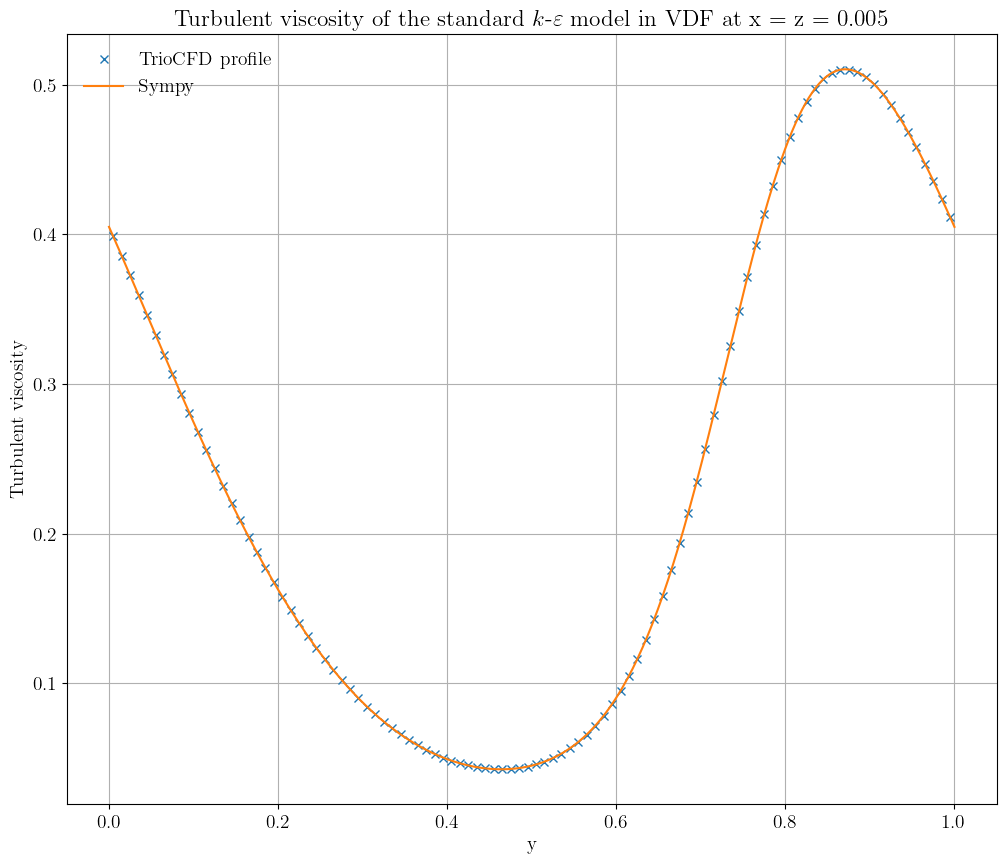

In [56]:
fig = plot.Graph(r"Turbulent viscosity of the standard $k$-$\varepsilon$ model in VDF at x = z = 0.005")

data = plot.loadText("./VDF_KEPS_STANDARD/nut.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile")

xval = numpy.linspace(0, 1, 500)
yval = nut_std(5e-3, xval, 5e-3)
fig.add(xval, yval, label="Sympy")

fig.label("y","Turbulent viscosity")

fig.visu()

### Convective terms

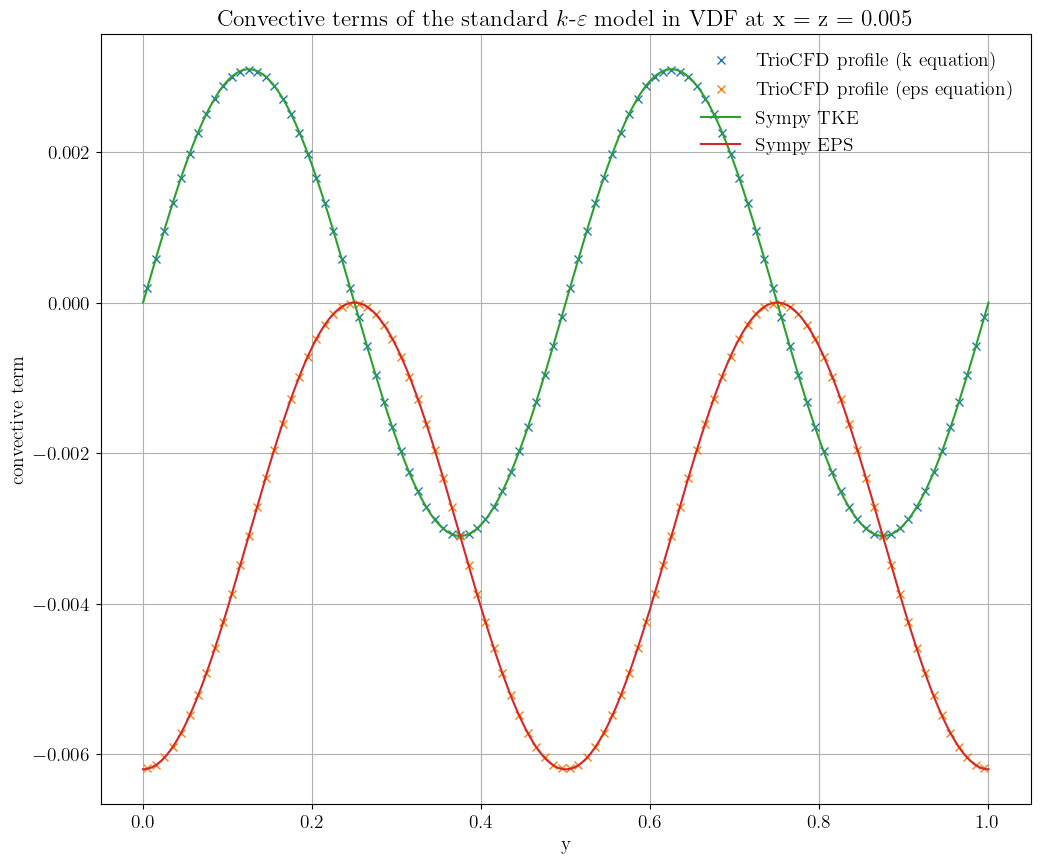

In [57]:
fig = plot.Graph(r"Convective terms of the standard $k$-$\varepsilon$ model in VDF at x = z = 0.005")

data = plot.loadText("./VDF_KEPS_STANDARD/conv_tke.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (k equation)")

data = plot.loadText("./VDF_KEPS_STANDARD/conv_eps.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (eps equation)")

xval = numpy.linspace(0, 1, 500)
yval = conv_tke_std(5e-3, xval, 5e-3)
fig.add(xval, -yval, label="Sympy TKE")
yval = conv_eps_std(5e-3, xval, 5e-3)
fig.add(xval, -yval, label="Sympy EPS")

fig.label("y","convective term")

fig.visu()


### Diffusive terms

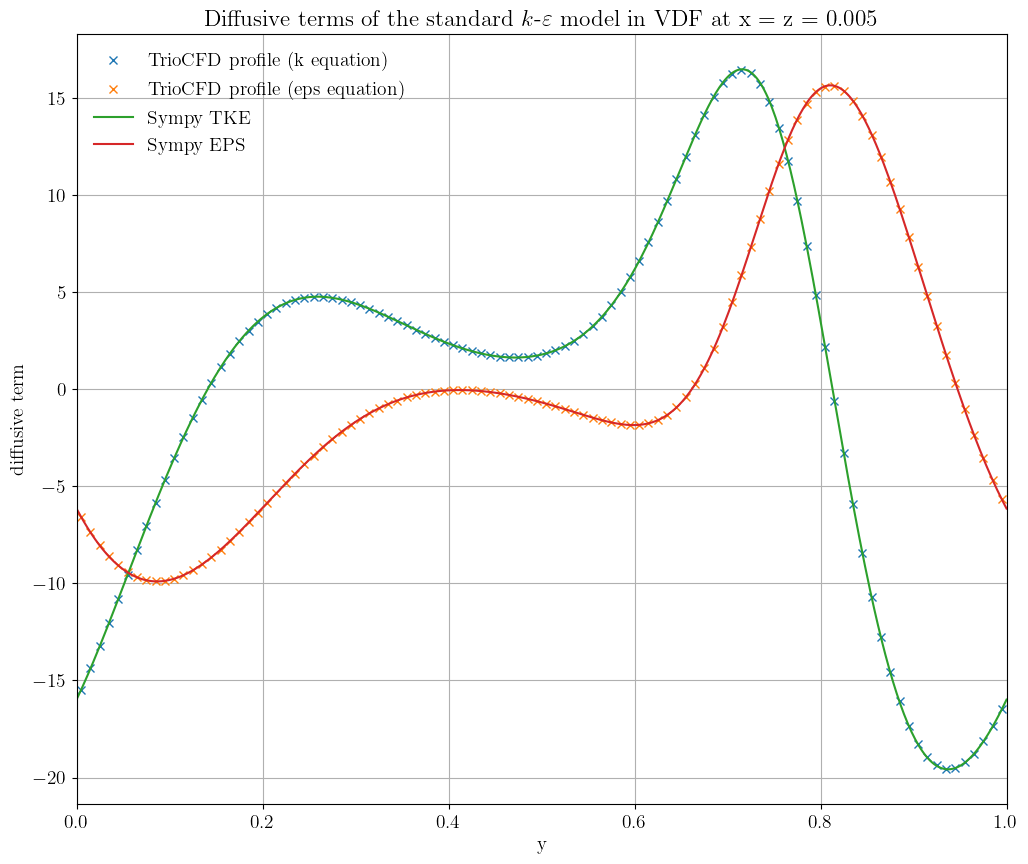

In [58]:
fig = plot.Graph(r"Diffusive terms of the standard $k$-$\varepsilon$ model in VDF at x = z = 0.005")

data = plot.loadText("./VDF_KEPS_STANDARD/diff_tke.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (k equation)")

data = plot.loadText("./VDF_KEPS_STANDARD/diff_eps.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (eps equation)")

xval = numpy.linspace(0, 1, 500)
yval = diff_tke_std(5e-3, xval, 5e-3)
fig.add(xval, yval, label="Sympy TKE")
yval = diff_eps_std(5e-3, xval, 5e-3)
fig.add(xval, yval, label="Sympy EPS")

fig.label(r"y",r"diffusive term")

fig.visu(xmin=0.0,xmax=1.0)


### Source terms

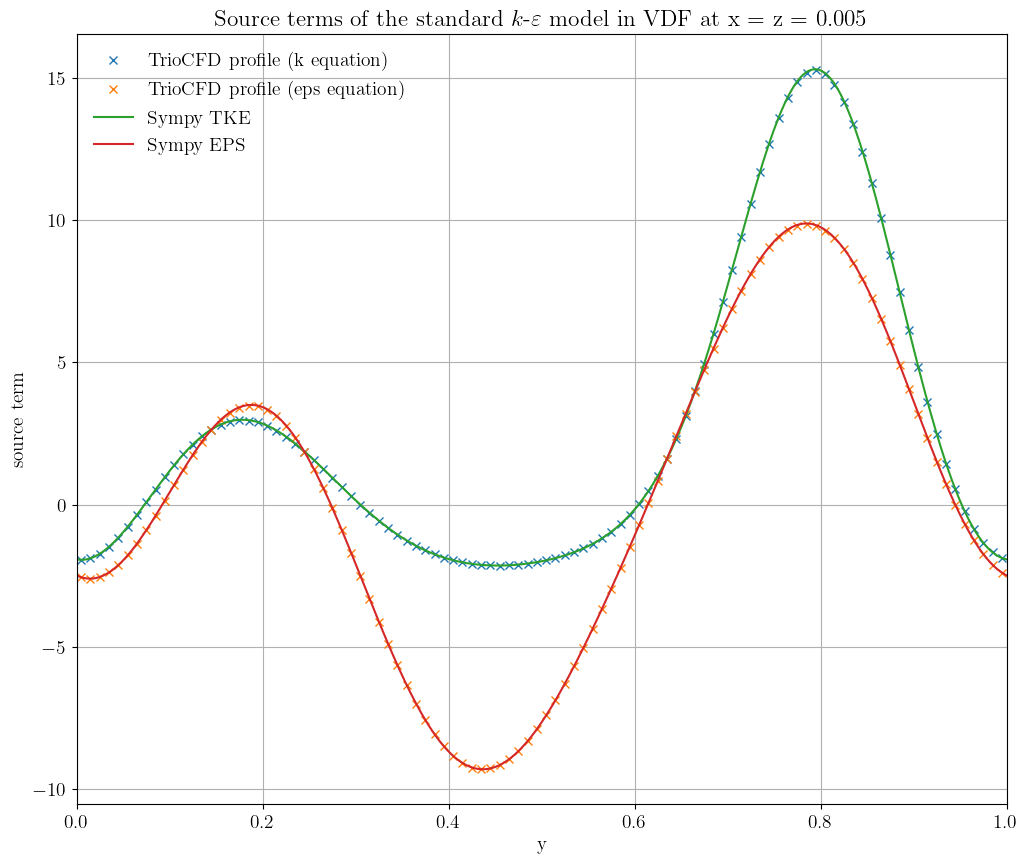

In [59]:
fig = plot.Graph(r"Source terms of the standard $k$-$\varepsilon$ model in VDF at x = z = 0.005")

data = plot.loadText("./VDF_KEPS_STANDARD/source_tke.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (k equation)")

data = plot.loadText("./VDF_KEPS_STANDARD/source_eps.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (eps equation)")

xval = numpy.linspace(0, 1, 500)
yval = sources_tke_std(5e-3, xval, 5e-3)
fig.add(xval, yval, label="Sympy TKE")
yval = sources_eps_std(5e-3, xval, 5e-3)
fig.add(xval, yval, label="Sympy EPS")

fig.label(r"y",r"source term")

fig.visu(xmin=0.0,xmax=1.0)


## VDF realizable $k$-$\varepsilon$ model


### Turbulent viscosity

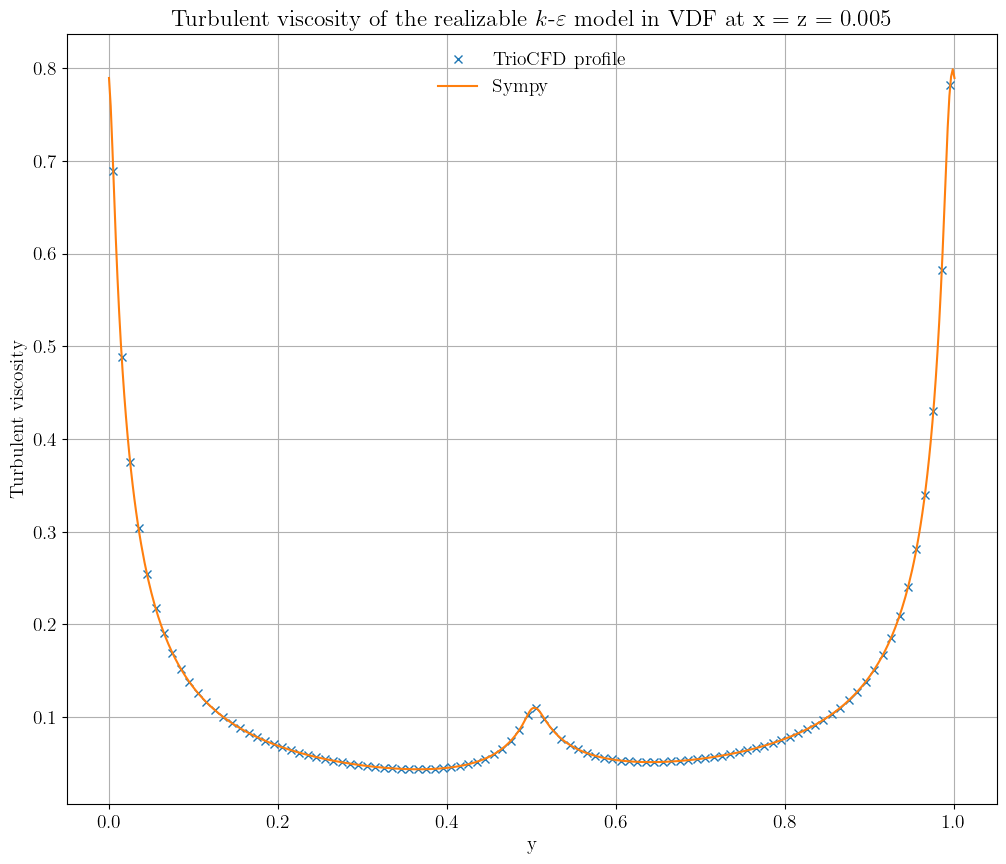

In [60]:
fig = plot.Graph(r"Turbulent viscosity of the realizable $k$-$\varepsilon$ model in VDF at x = z = 0.005")

data = plot.loadText("./VDF_KEPS_REALISABLE/nut.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile")

xval = numpy.linspace(0, 1, 500)
yval = nut_rea(5e-3, xval, 5e-3)
fig.add(xval, yval, label="Sympy")

fig.label("y","Turbulent viscosity")

fig.visu()

### Convective terms

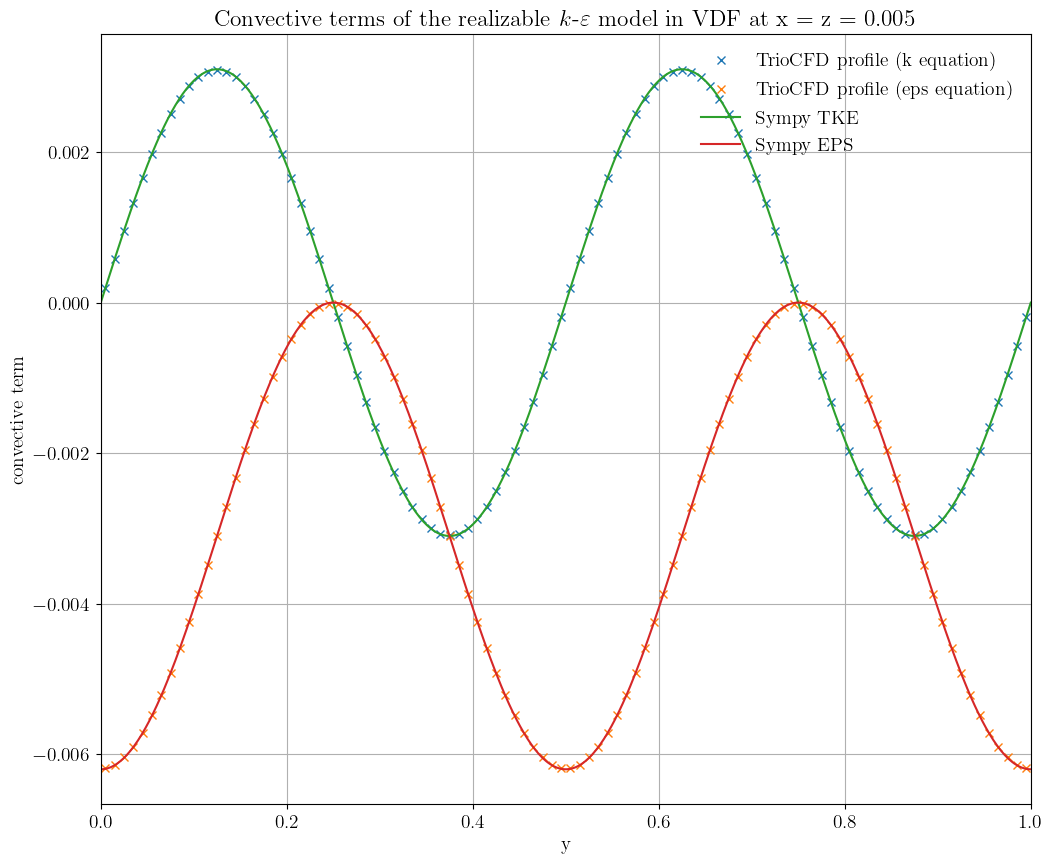

In [61]:
fig = plot.Graph(r"Convective terms of the realizable $k$-$\varepsilon$ model in VDF at x = z = 0.005")

data = plot.loadText("./VDF_KEPS_REALISABLE/conv_tke.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (k equation)")

data = plot.loadText("./VDF_KEPS_REALISABLE/conv_eps.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (eps equation)")

xval = numpy.linspace(0, 1, 500)
yval = conv_tke_rea(5e-3, xval, 5e-3)
fig.add(xval, -yval, label="Sympy TKE")
yval = conv_eps_rea(5e-3, xval, 5e-3)
fig.add(xval, -yval, label="Sympy EPS")

fig.label(r"y", r"convective term")

fig.visu(xmin=0.0, xmax=1.0)


### Diffusive terms

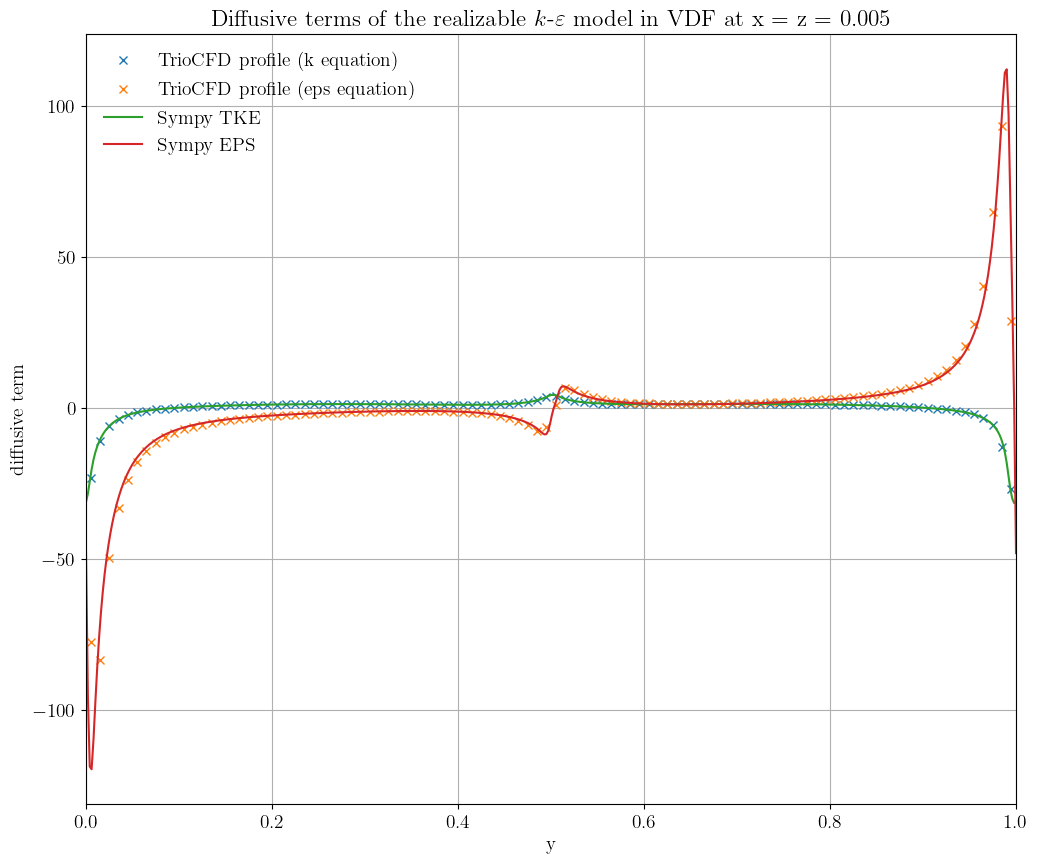

In [62]:
fig = plot.Graph(r"Diffusive terms of the realizable $k$-$\varepsilon$ model in VDF at x = z = 0.005")

data = plot.loadText("./VDF_KEPS_REALISABLE/diff_tke.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (k equation)")

data = plot.loadText("./VDF_KEPS_REALISABLE/diff_eps.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (eps equation)")

xval = numpy.linspace(0, 1, 500)
yval = diff_tke_rea(5e-3, xval, 5e-3)
fig.add(xval, yval, label="Sympy TKE")
yval = diff_eps_rea(5e-3, xval, 5e-3)
fig.add(xval, yval, label="Sympy EPS")

fig.label(r"y",r"diffusive term")

fig.visu(xmin=0.0,xmax=1.0)


### Source terms

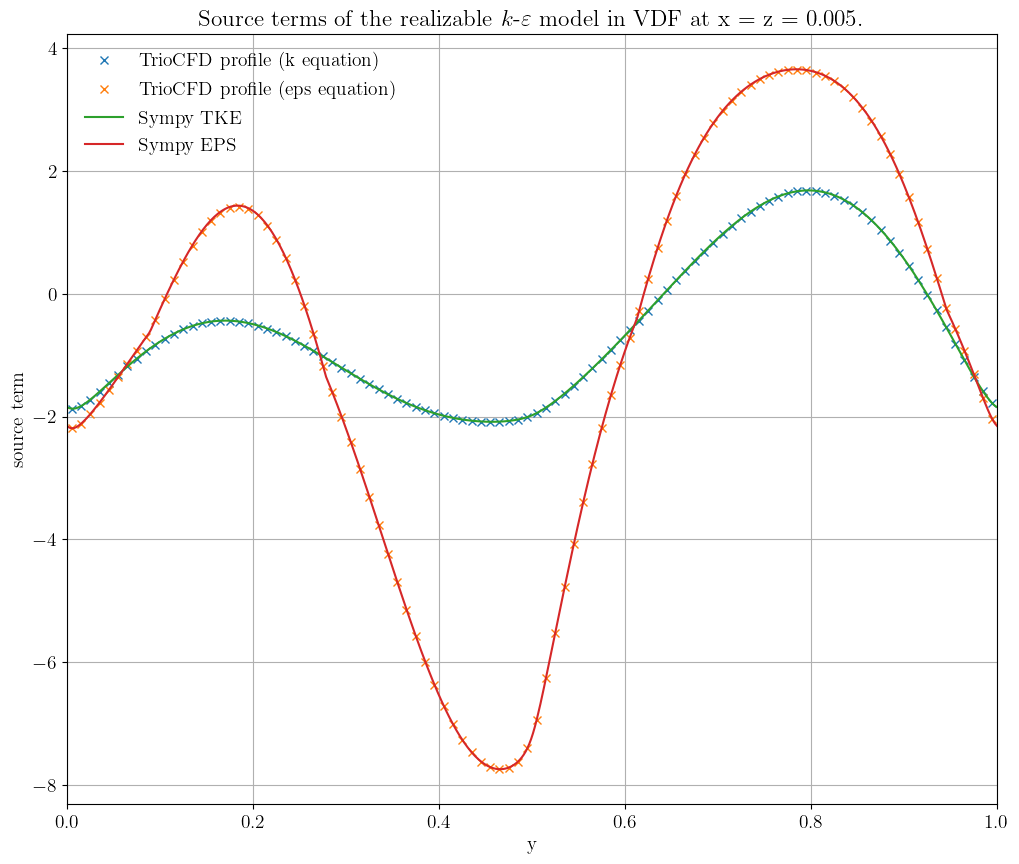

In [63]:
fig = plot.Graph(r"Source terms of the realizable $k$-$\varepsilon$ model in VDF at x = z = 0.005.")

data = plot.loadText("./VDF_KEPS_REALISABLE/source_tke.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (k equation)")

data = plot.loadText("./VDF_KEPS_REALISABLE/source_eps.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (eps equation)")

xval = numpy.linspace(0, 1, 500)
yval = numpy.array([sources_tke_rea(5e-3, y, 5e-3) for y in xval])
fig.add(xval, yval, label="Sympy TKE")
yval = numpy.array([sources_eps_rea(5e-3, y, 5e-3) for y in xval])
fig.add(xval, yval, label="Sympy EPS")

fig.label(r"y",r"source term")

fig.visu(xmin=0.0,xmax=1.0)


## VEF standard $k$-$\varepsilon$ model


### Turbulent viscosity

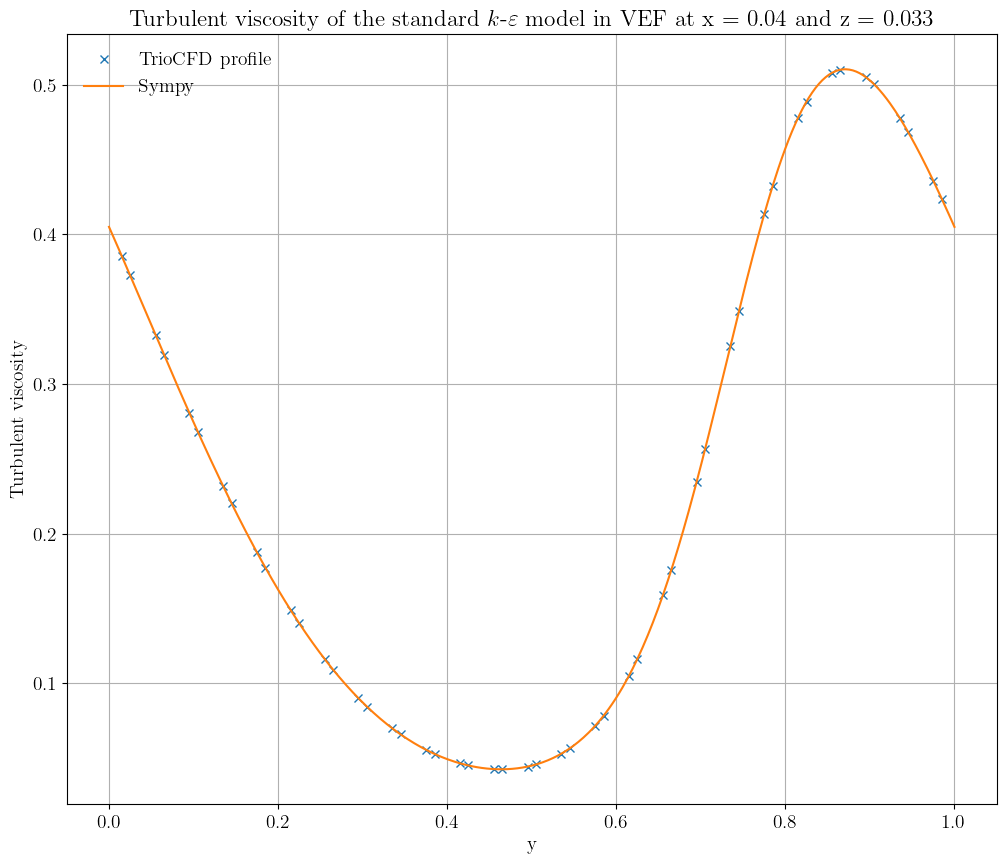

In [64]:
fig = plot.Graph(r"Turbulent viscosity of the standard $k$-$\varepsilon$ model in VEF at x = 0.04 and z = 0.033")

data = plot.loadText("./VEF_KEPS_STANDARD/nut.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile")

xval = numpy.linspace(0, 1, 500)
yval = nut_std(4e-2, xval, 1/30)
fig.add(xval, yval, label="Sympy")

fig.label("y","Turbulent viscosity")

fig.visu()

### Convective terms

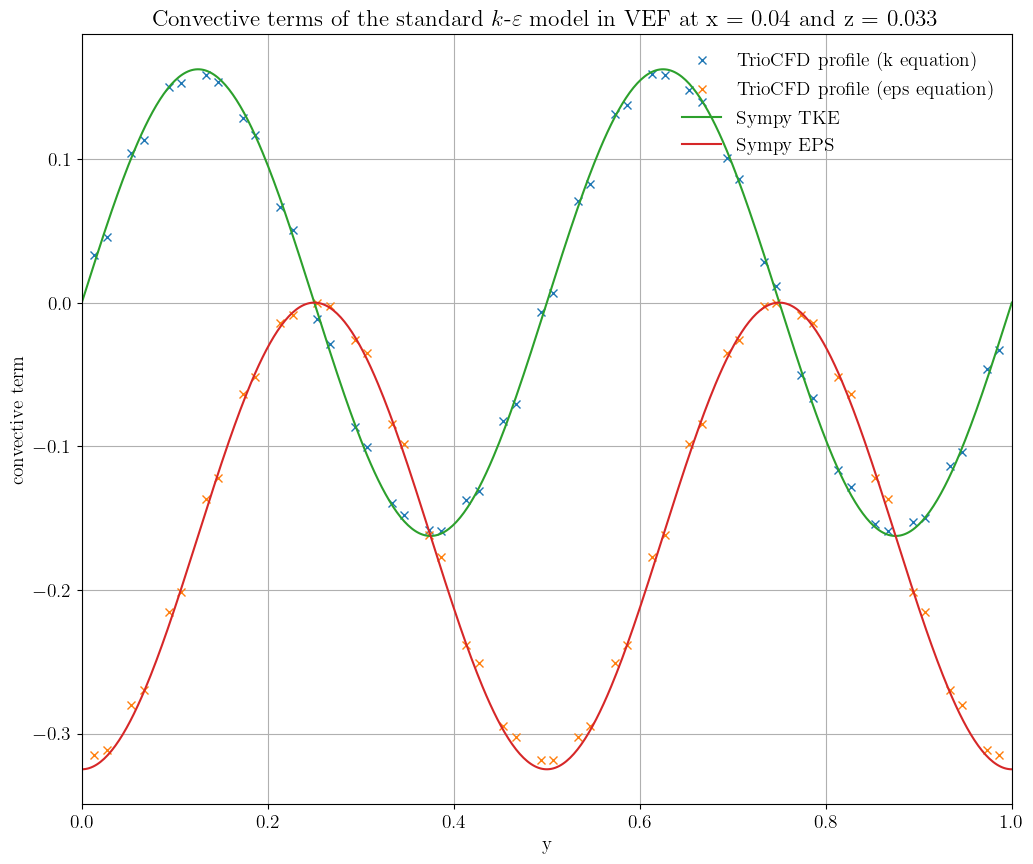

In [65]:
fig = plot.Graph(r"Convective terms of the standard $k$-$\varepsilon$ model in VEF at x = 0.04 and z = 0.033")

data = plot.loadText("./VEF_KEPS_STANDARD/conv_tke.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (k equation)")

data = plot.loadText("./VEF_KEPS_STANDARD/conv_eps.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (eps equation)")

xval = numpy.linspace(0, 1, 500)
yval = conv_tke_std(4e-2, xval, 1/30)
fig.add(xval, -yval, label="Sympy TKE")
yval = conv_eps_std(4e-2, xval, 1/30)
fig.add(xval, -yval, label="Sympy EPS")

fig.label(r"y",r"convective term")

fig.visu(xmin=0.0,xmax=1.0)


### Diffusive terms

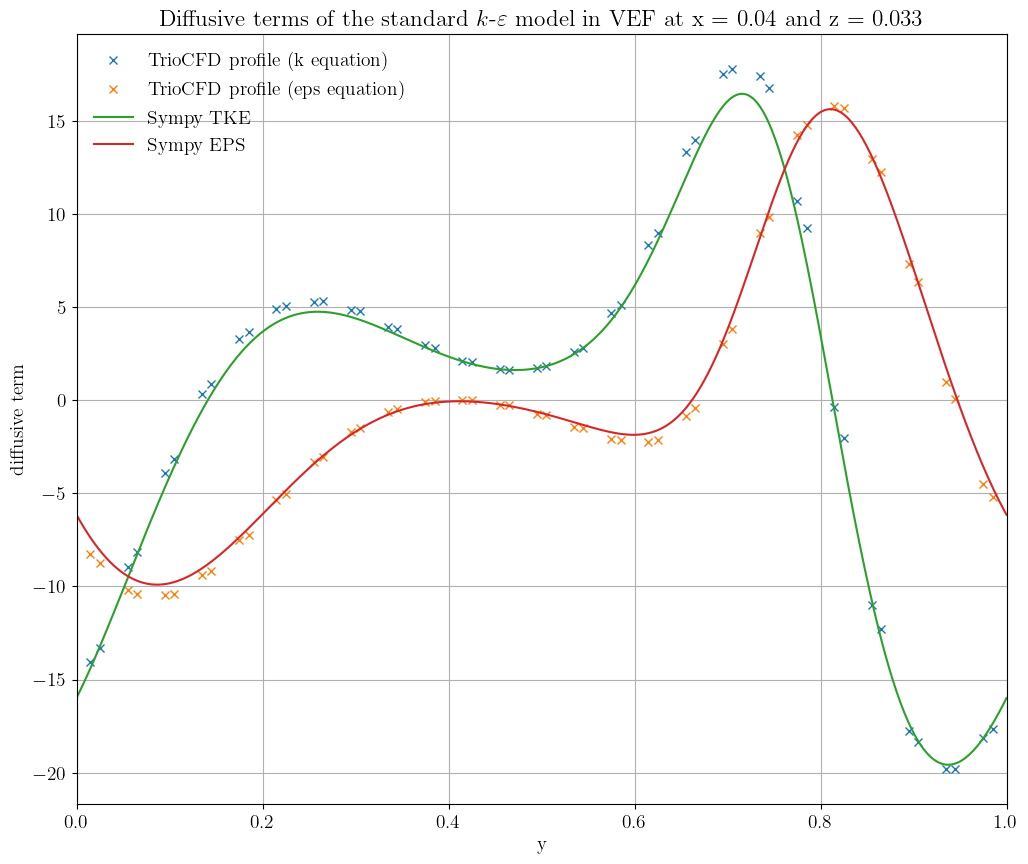

In [66]:
fig = plot.Graph(r"Diffusive terms of the standard $k$-$\varepsilon$ model in VEF at x = 0.04 and z = 0.033")

data = plot.loadText("./VEF_KEPS_STANDARD/diff_tke.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (k equation)")

data = plot.loadText("./VEF_KEPS_STANDARD/diff_eps.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (eps equation)")

xval = numpy.linspace(0, 1, 500)
yval = diff_tke_std(4e-2, xval, 1/30)
fig.add(xval, yval, label="Sympy TKE")
yval = diff_eps_std(4e-2, xval, 1/30)
fig.add(xval, yval, label="Sympy EPS")

fig.label(r"y",r"diffusive term")

fig.visu(xmin=0.0,xmax=1.0)


### Source terms

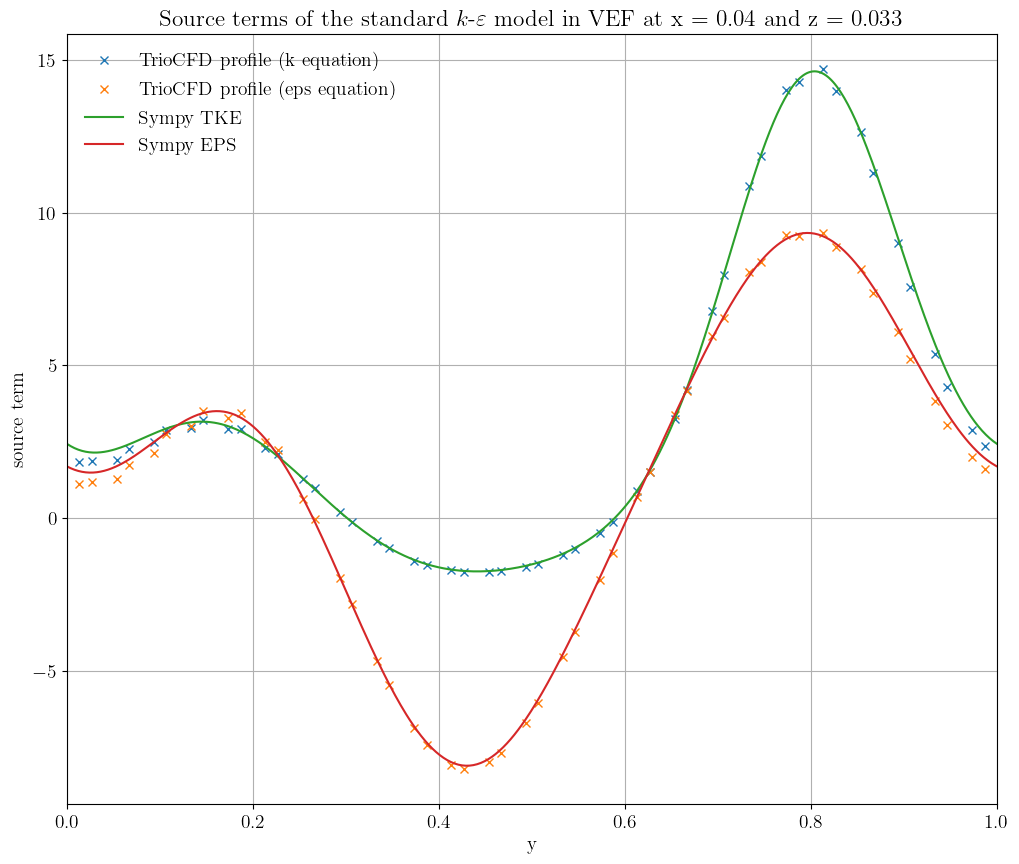

In [67]:
fig = plot.Graph(r"Source terms of the standard $k$-$\varepsilon$ model in VEF at x = 0.04 and z = 0.033")

data = plot.loadText("./VEF_KEPS_STANDARD/source_tke.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (k equation)")

data = plot.loadText("./VEF_KEPS_STANDARD/source_eps.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (eps equation)")

xval = numpy.linspace(0, 1, 500)
yval = sources_tke_std(4e-2, xval, 1/30)
fig.add(xval, yval, label="Sympy TKE")
yval = sources_eps_std(4e-2, xval, 1/30)
fig.add(xval, yval, label="Sympy EPS")

fig.label(r"y",r"source term")

fig.visu(xmin=0.0,xmax=1.0)


## VEF realizable $k$-$\varepsilon$ model


### Turbulent viscosity

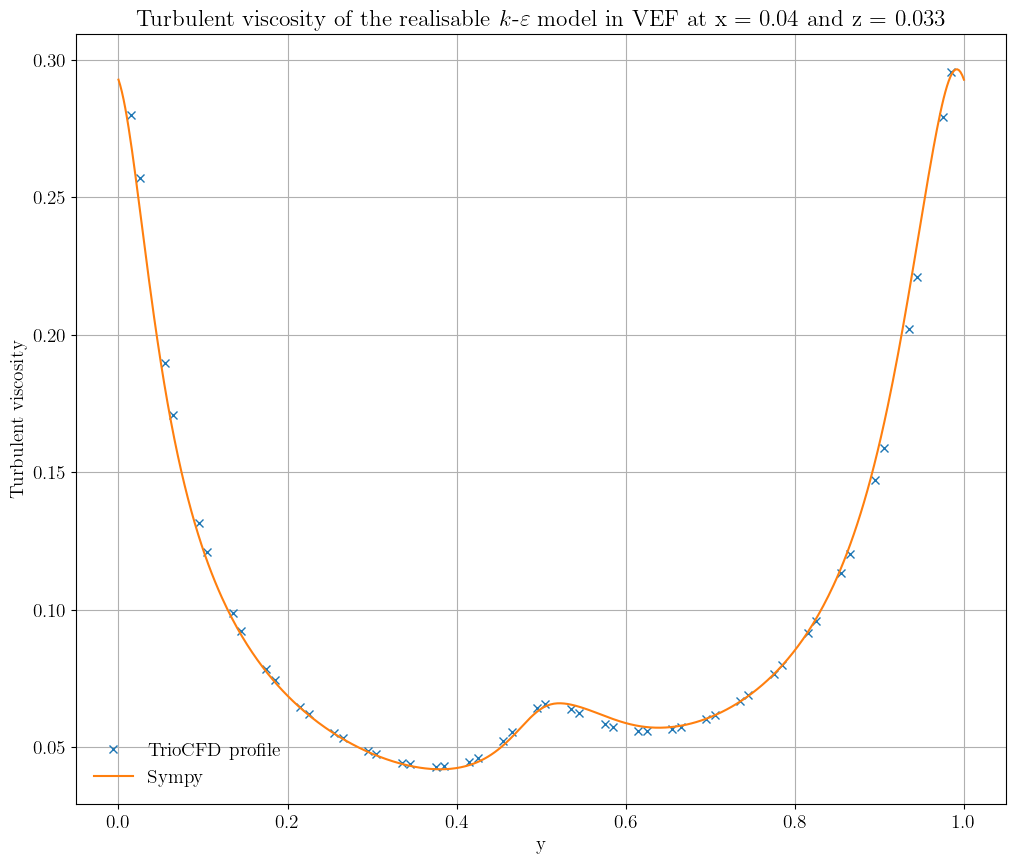

In [68]:
fig = plot.Graph(r"Turbulent viscosity of the realisable $k$-$\varepsilon$ model in VEF at x = 0.04 and z = 0.033")

data = plot.loadText("./VEF_KEPS_REALISABLE/nut.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile")

xval = numpy.linspace(0, 1, 500)
yval = nut_rea(4e-2, xval, 1/30)
fig.add(xval, yval, label="Sympy")

fig.label("y","Turbulent viscosity")

fig.visu()

### Convective terms

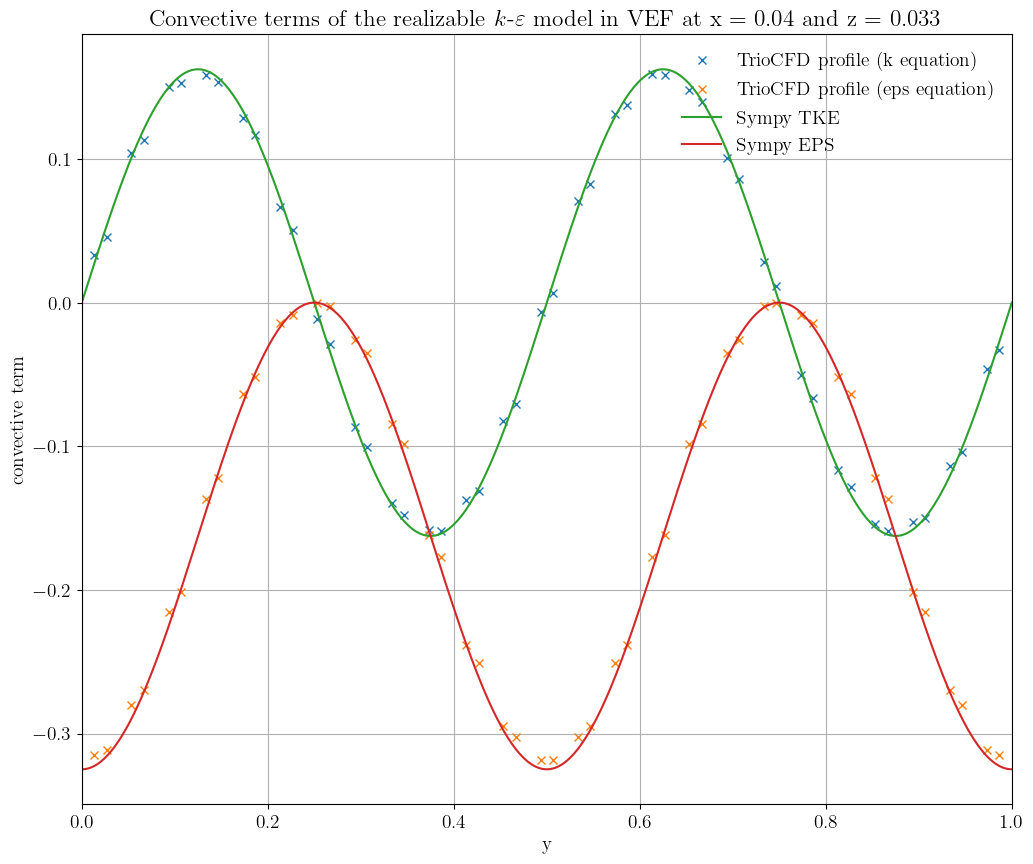

In [69]:
fig = plot.Graph(r"Convective terms of the realizable $k$-$\varepsilon$ model in VEF at x = 0.04 and z = 0.033")

data = plot.loadText("./VEF_KEPS_REALISABLE/conv_tke.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (k equation)")

data = plot.loadText("./VEF_KEPS_REALISABLE/conv_eps.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (eps equation)")

xval = numpy.linspace(0, 1, 500)
yval = conv_tke_rea(4e-2, xval, 1/30)
fig.add(xval, -yval, label="Sympy TKE")
yval = conv_eps_rea(4e-2, xval, 1/30)
fig.add(xval, -yval, label="Sympy EPS")

fig.label(r"y",r"convective term")

fig.visu(xmin=0.0,xmax=1.0)


### Diffusive terms

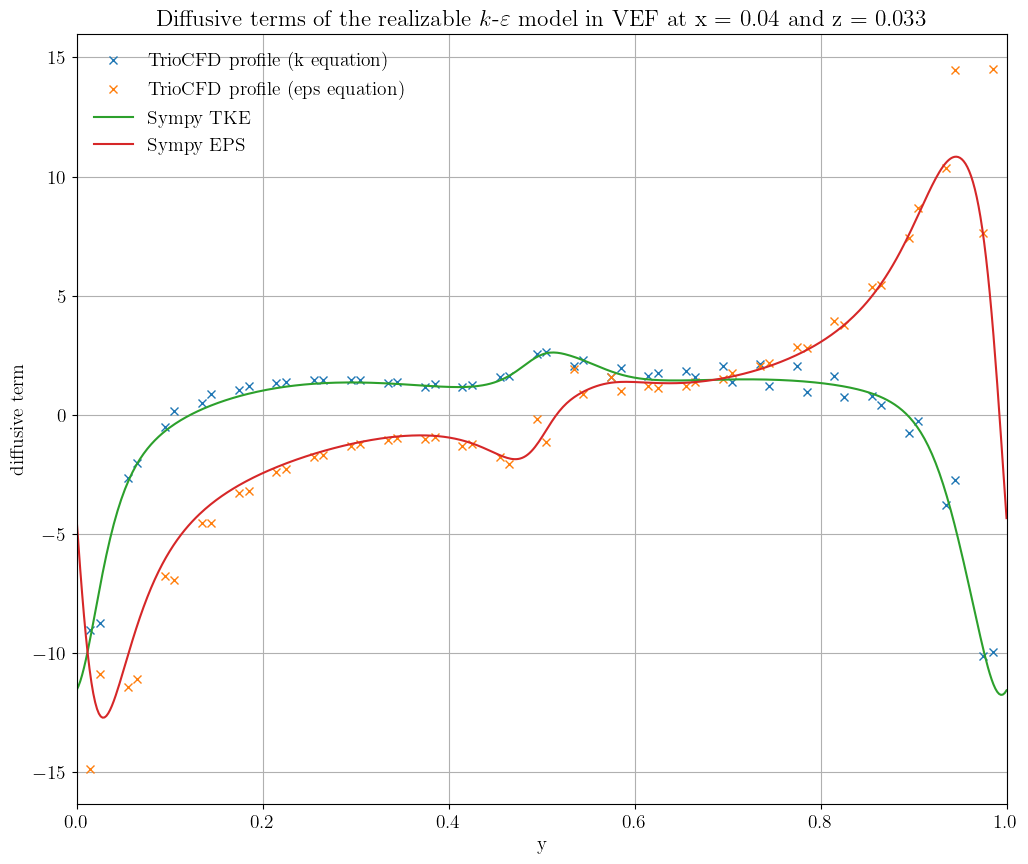

In [70]:
fig = plot.Graph(r"Diffusive terms of the realizable $k$-$\varepsilon$ model in VEF at x = 0.04 and z = 0.033")

data = plot.loadText("./VEF_KEPS_REALISABLE/diff_tke.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (k equation)")

data = plot.loadText("./VEF_KEPS_REALISABLE/diff_eps.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (eps equation)")

xval = numpy.linspace(0, 1, 500)
yval = diff_tke_rea(4e-2, xval, 1/30)
fig.add(xval, yval, label="Sympy TKE")
yval = diff_eps_rea(4e-2, xval, 1/30)
fig.add(xval, yval, label="Sympy EPS")

fig.label(r"y",r"diffusive term")

fig.visu(xmin=0.0,xmax=1.0)


### Source terms

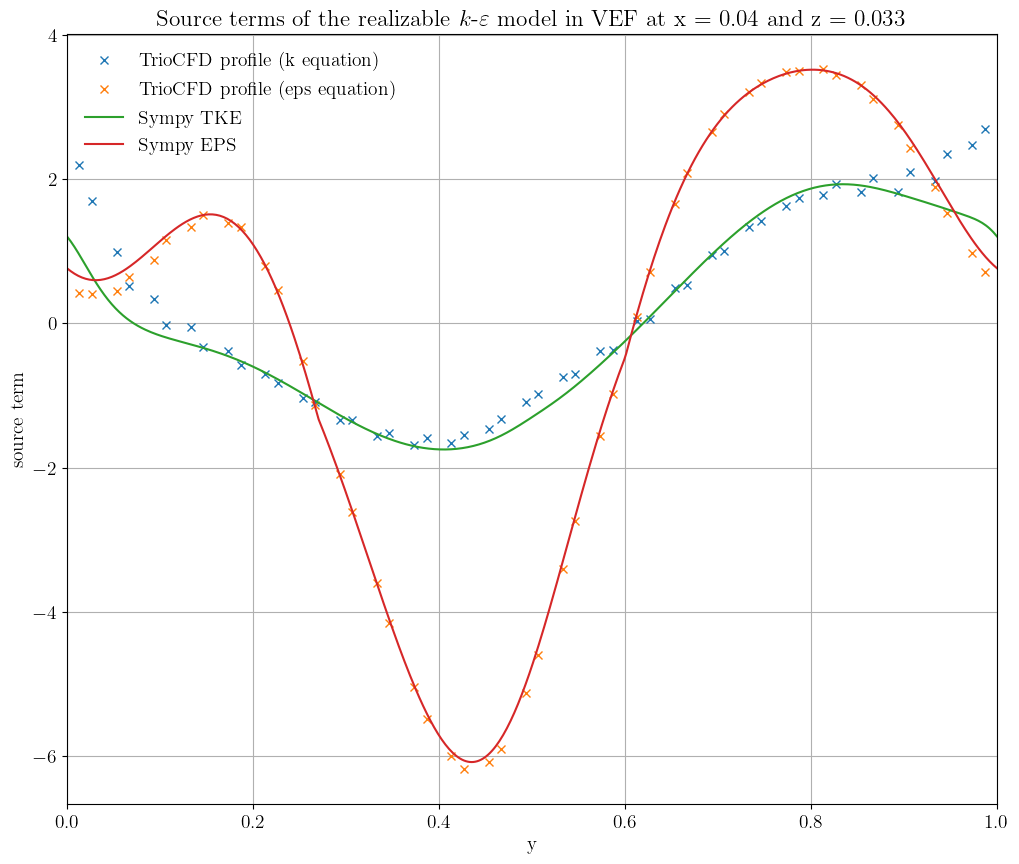

In [71]:
fig = plot.Graph(r"Source terms of the realizable $k$-$\varepsilon$ model in VEF at x = 0.04 and z = 0.033")

data = plot.loadText("./VEF_KEPS_REALISABLE/source_tke.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (k equation)")

data = plot.loadText("./VEF_KEPS_REALISABLE/source_eps.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (eps equation)")

xval = numpy.linspace(0, 1, 500)
yval = sources_tke_rea(4e-2, xval, 1/30)
fig.add(xval, yval, label="Sympy TKE")
yval = numpy.array([sources_eps_rea(4e-2, y, 1/30) for y in xval])
fig.add(xval, yval, label="Sympy EPS")

fig.label(r"y",r"source term")

fig.visu(xmin=0.0, xmax=1.0)


## VDF standard $k$-$\omega$ model

### Turbulent viscosity 

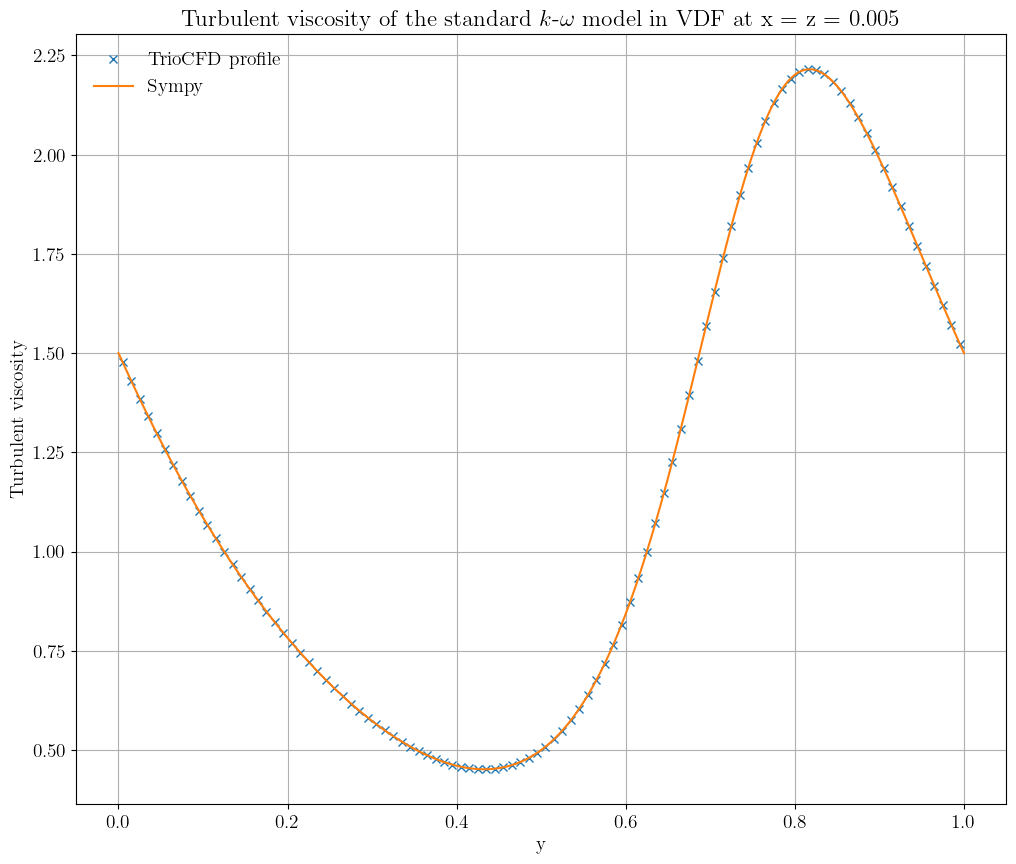

In [72]:
fig = plot.Graph(r"Turbulent viscosity of the standard $k$-$\omega$ model in VDF at x = z = 0.005")

data = plot.loadText("./VDF_KOMG_STANDARD/nut.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile")

xval = numpy.linspace(0, 1, 500)
yval = nut_omg(5e-3, xval, 5e-3)
fig.add(xval, yval, label="Sympy")

fig.label("y","Turbulent viscosity")

fig.visu()

### Convective terms

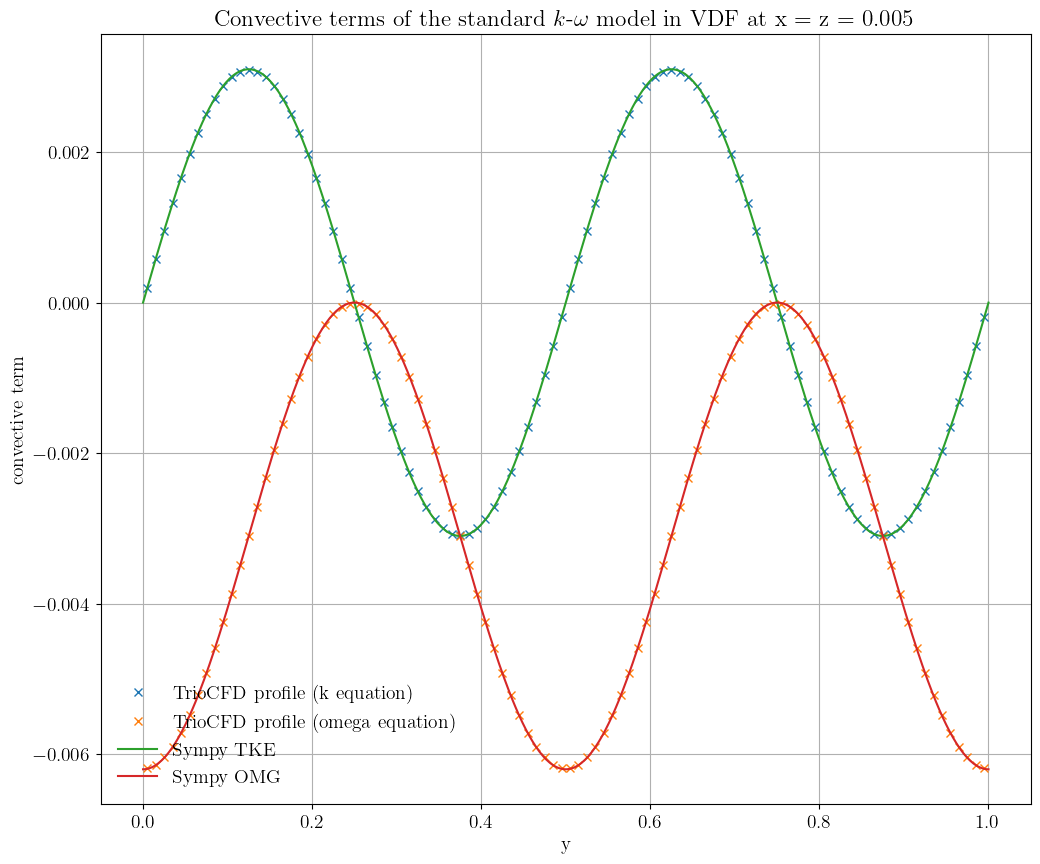

In [73]:
fig = plot.Graph(r"Convective terms of the standard $k$-$\omega$ model in VDF at x = z = 0.005")

data = plot.loadText("./VDF_KOMG_STANDARD/conv_tke.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (k equation)")

data = plot.loadText("./VDF_KOMG_STANDARD/conv_omega.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (omega equation)")

xval = numpy.linspace(0, 1, 500)
yval = conv_tke4omg_std(5e-3, xval, 5e-3)
fig.add(xval, -yval, label="Sympy TKE")
yval = conv_omg_std(5e-3, xval, 5e-3)
fig.add(xval, -yval, label="Sympy OMG")

fig.label("y","convective term")

fig.visu()


### Diffusive terms

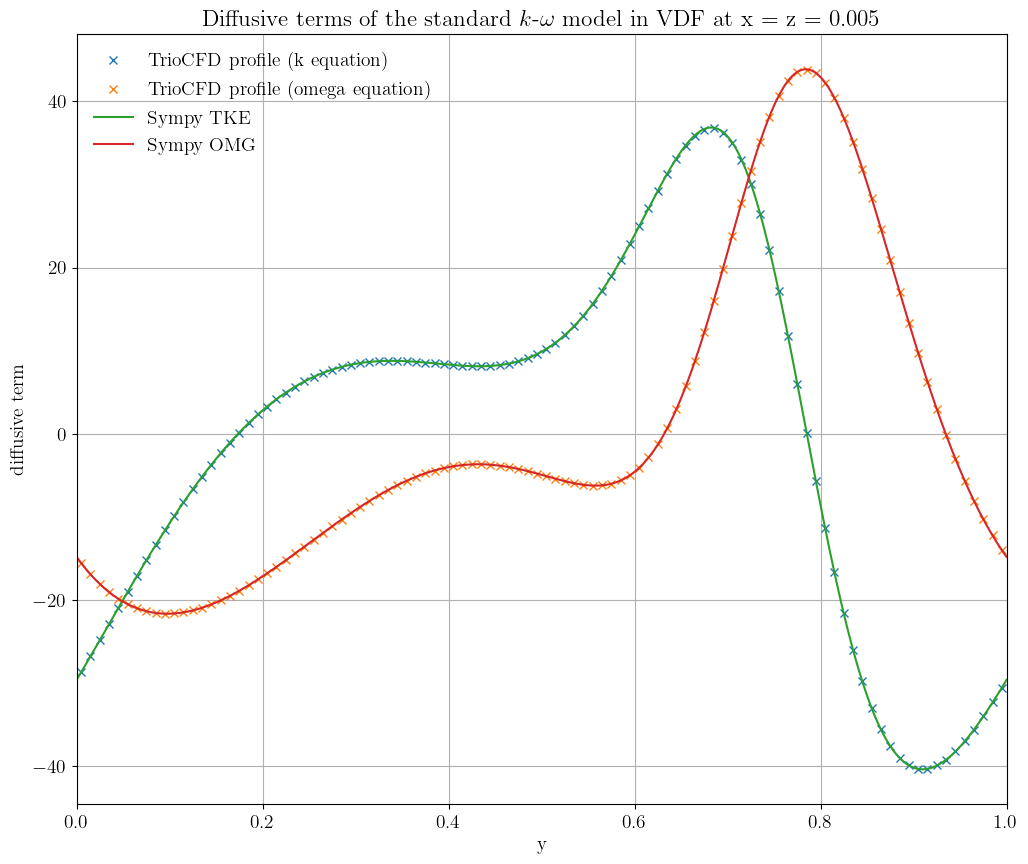

In [74]:
fig = plot.Graph(r"Diffusive terms of the standard $k$-$\omega$ model in VDF at x = z = 0.005")

data = plot.loadText("./VDF_KOMG_STANDARD/diff_tke.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (k equation)")

data = plot.loadText("./VDF_KOMG_STANDARD/diff_omega.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (omega equation)")

xval = numpy.linspace(0, 1, 500)
yval = diff_tke4omg_std(5e-3, xval, 5e-3)
fig.add(xval, yval, label="Sympy TKE")
yval = diff_omg_std(5e-3, xval, 5e-3)
fig.add(xval, yval, label="Sympy OMG")

fig.label(r"y",r"diffusive term")

fig.visu(xmin=0.0,xmax=1.0)


### Source terms

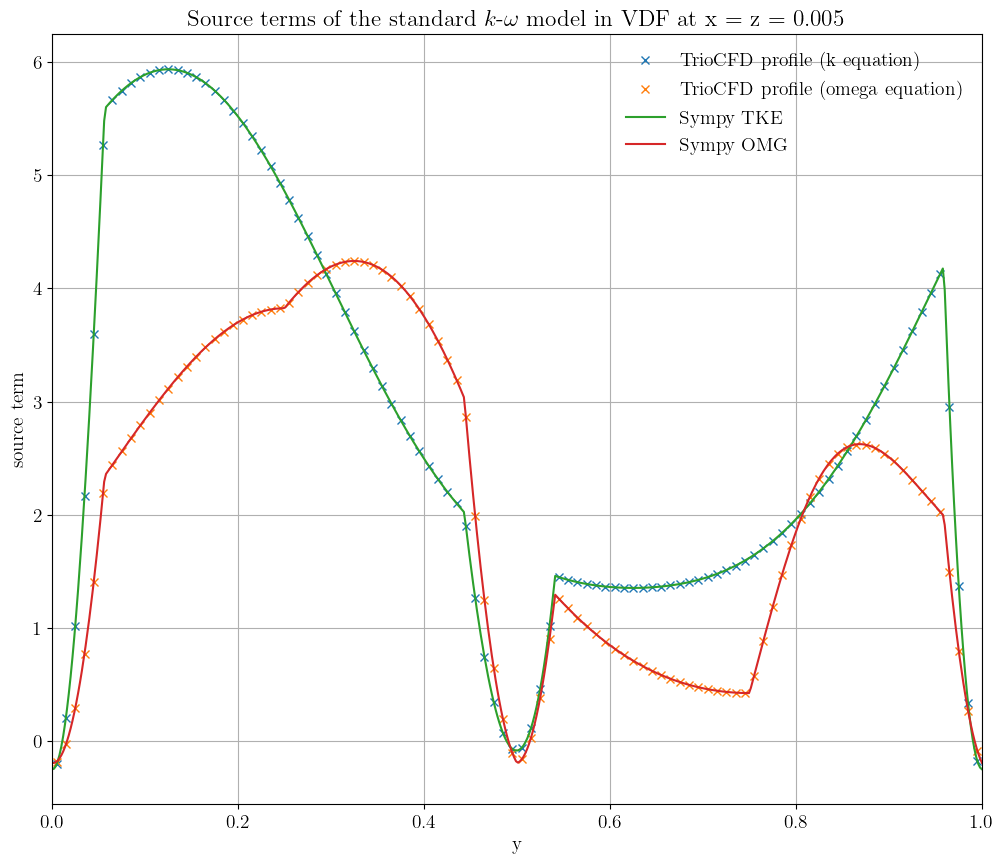

In [75]:
fig = plot.Graph(r"Source terms of the standard $k$-$\omega$ model in VDF at x = z = 0.005")

data = plot.loadText("./VDF_KOMG_STANDARD/source_tke.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (k equation)")

data = plot.loadText("./VDF_KOMG_STANDARD/source_omega.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (omega equation)")

xval = numpy.linspace(0, 1, 500)
yval = sources_tke4omg_std(5e-3, xval, 5e-3)
fig.add(xval, yval, label="Sympy TKE")
yval = sources_omg_std(5e-3, xval, 5e-3)
fig.add(xval, yval, label="Sympy OMG")

fig.label(r"y",r"source term")

fig.visu(xmin=0.0,xmax=1.0)


## VEF standard $k$-$\omega$ model

### Turbulent viscosity 

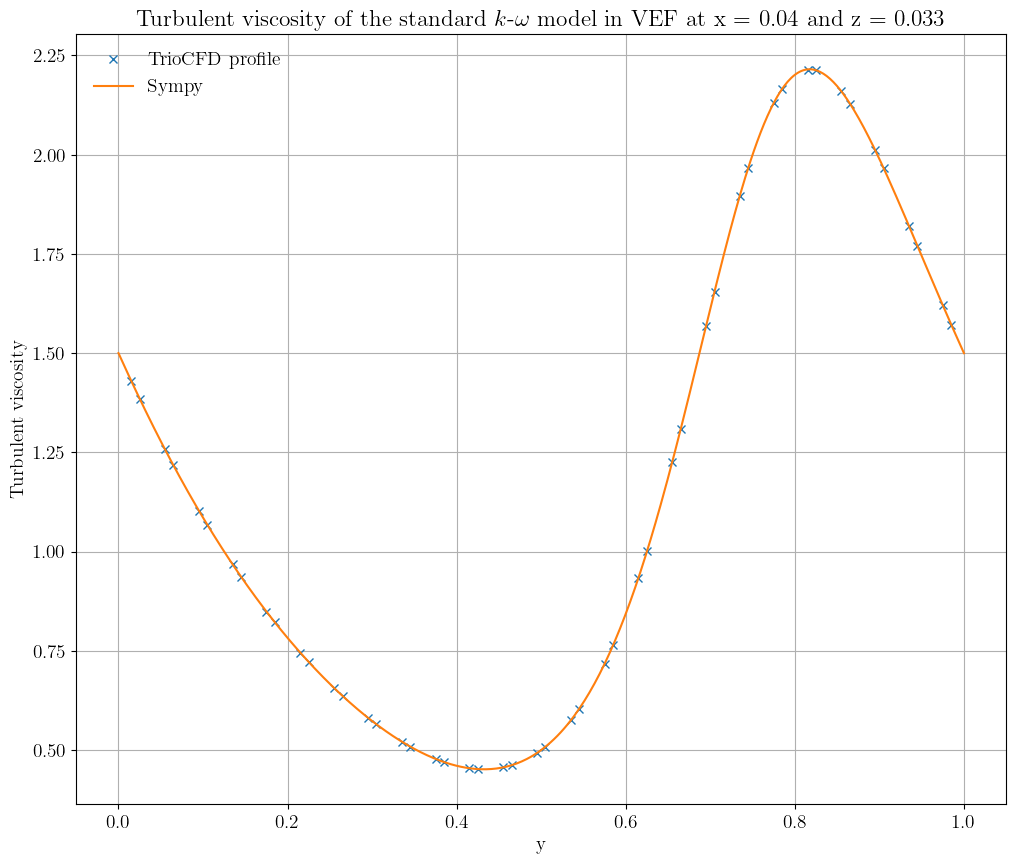

In [76]:
fig = plot.Graph(r"Turbulent viscosity of the standard $k$-$\omega$ model in VEF at x = 0.04 and z = 0.033")

data = plot.loadText("./VEF_KOMG_STANDARD/nut.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile")

xval = numpy.linspace(0, 1, 500)
yval = nut_omg(4e-2, xval, 1/30)
fig.add(xval, yval, label="Sympy")

fig.label("y","Turbulent viscosity")

fig.visu()

### Convective terms

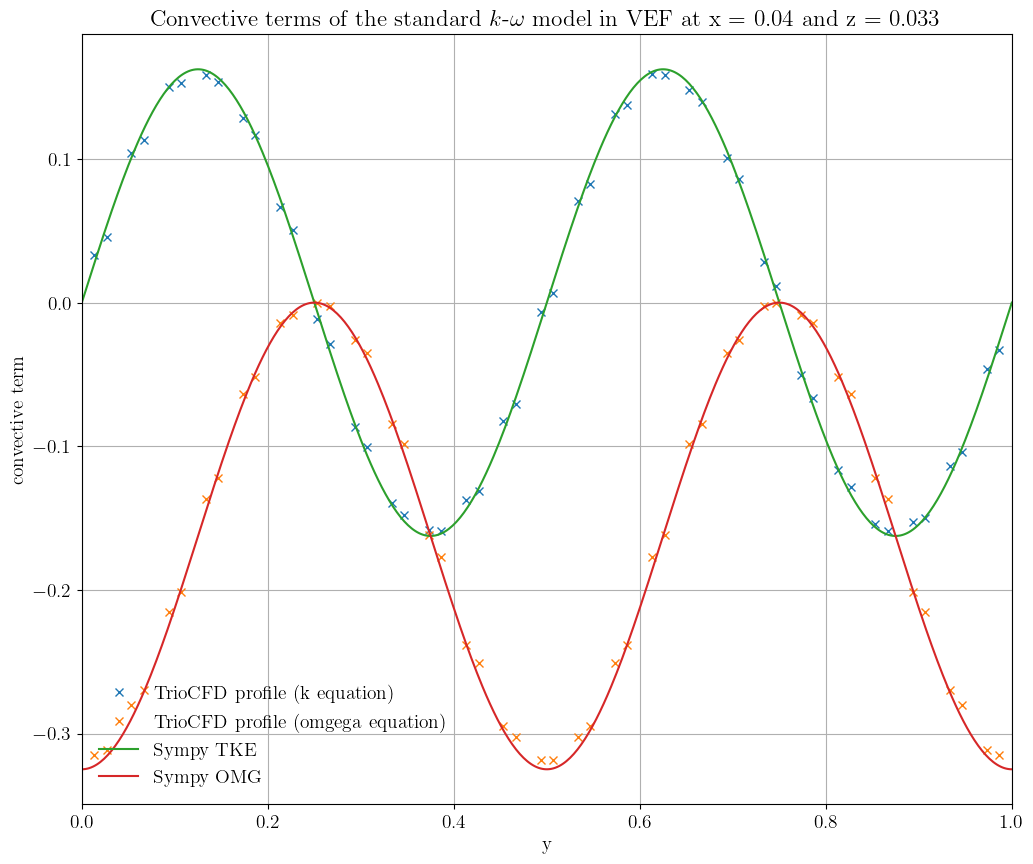

In [77]:
fig = plot.Graph(r"Convective terms of the standard $k$-$\omega$ model in VEF at x = 0.04 and z = 0.033")

data = plot.loadText("./VEF_KOMG_STANDARD/conv_tke.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (k equation)")

data = plot.loadText("./VEF_KOMG_STANDARD/conv_omega.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (omgega equation)")

xval = numpy.linspace(0, 1, 500)
yval = conv_tke4omg_std(4e-2, xval, 1/30)
fig.add(xval, -yval, label="Sympy TKE")
yval = conv_omg_std(4e-2, xval, 1/30)
fig.add(xval, -yval, label="Sympy OMG")

fig.label(r"y",r"convective term")

fig.visu(xmin=0.0,xmax=1.0)


### Diffusive terms

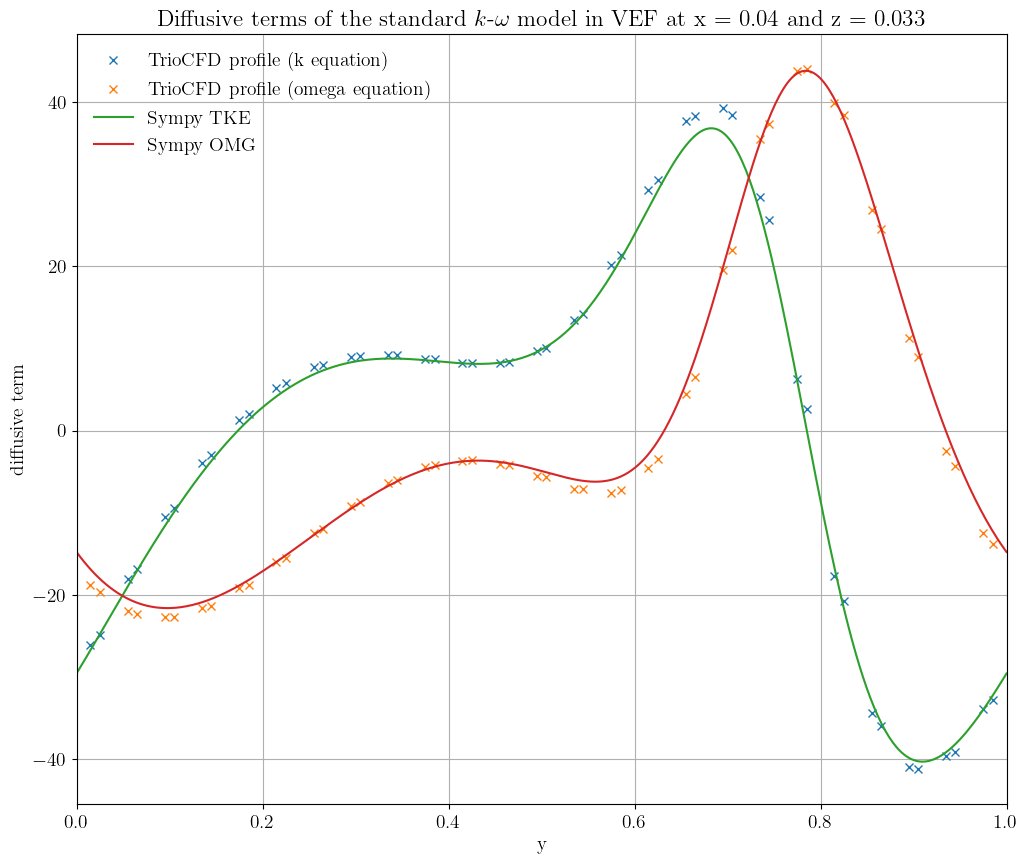

In [78]:
fig = plot.Graph(r"Diffusive terms of the standard $k$-$\omega$ model in VEF at x = 0.04 and z = 0.033")

data = plot.loadText("./VEF_KOMG_STANDARD/diff_tke.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (k equation)")

data = plot.loadText("./VEF_KOMG_STANDARD/diff_omega.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (omega equation)")

xval = numpy.linspace(0, 1, 500)
yval = diff_tke4omg_std(4e-2, xval, 1/30)
fig.add(xval, yval, label="Sympy TKE")
yval = diff_omg_std(4e-2, xval, 1/30)
fig.add(xval, yval, label="Sympy OMG")

fig.label(r"y",r"diffusive term")

fig.visu(xmin=0.0,xmax=1.0)


### Source terms

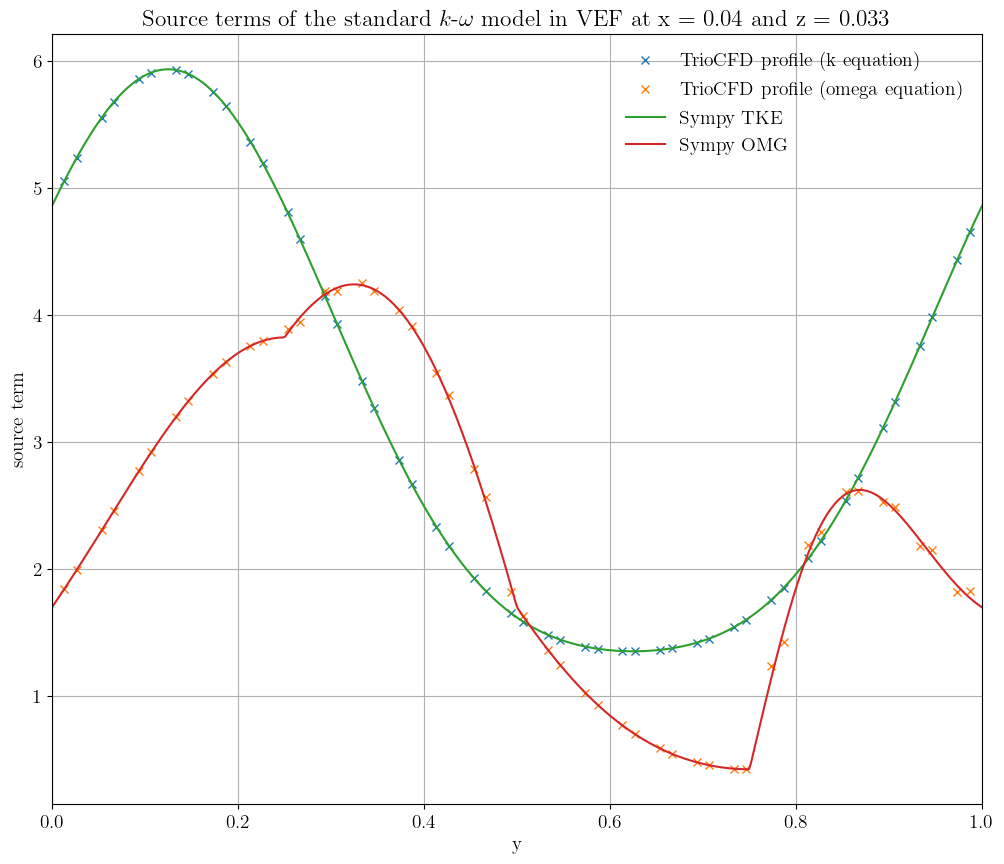

In [79]:
fig = plot.Graph(r"Source terms of the standard $k$-$\omega$ model in VEF at x = 0.04 and z = 0.033")

data = plot.loadText("./VEF_KOMG_STANDARD/source_tke.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (k equation)")

data = plot.loadText("./VEF_KOMG_STANDARD/source_omega.dat")
fig.add((data[0]),(data[1]),marker="x",label=r"TrioCFD profile (omega equation)")

xval = numpy.linspace(0, 1, 500)
yval = sources_tke4omg_std(4e-2, xval, 1/30)
fig.add(xval, yval, label="Sympy TKE")
yval = sources_omg_std(4e-2, xval, 1/30)
fig.add(xval, yval, label="Sympy OMG")

fig.label(r"y",r"source term")

fig.visu(xmin=0.0,xmax=1.0)


# Conclusion 
 
In this report, the coding of the diffusive, convective and source terms of the $k$ and $\varepsilon$ transport equations have been verified for the standard and realizable models. The standard $k$-$\omega$ model was also verified. Analytical fields of velocity, $k$, $\varepsilon$ and $\omega$ have been imposed in input, and the terms of equations have been post-processed without resolution. The TrioCFD output profiles have been shown to be almost superimposed with the analytical profiles. It should also be noted that terms involving derivatives are less accurate in VEF discretization, especially near the boundaries. A refinement of the mesh would likely result in a higher accuracy.

# References
 
[1] P.-E. Angeli et G. Damblin, Calage des paramètres du modéle $k$-$\varepsilon$ réalisable par algorithmes EGO pour la simulation des écoulements turbulents, note technique DES/ISAS/DM2S/STMF/LMSF/NT/2020-66507/A.


# Data Files

## Cas

In [80]:
run.dumpDatasetMD("VDF_KEPS_STANDARD/Cas.data")

```
Dimension 3
Pb_hydraulique_turbulent pb

Domaine dom
Mailler dom
{
    pave bloc
    {
        origine 0 0 0
        longueurs 1 1 1
        nombre_de_noeuds 101 101 101
    }
    {
        bord periox  X = 0  0 <= Y <= 1  0 <= Z <= 1
        bord periox  X = 1  0 <= Y <= 1  0 <= Z <= 1
        bord perioy  Y = 0  0 <= X <= 1  0 <= Z <= 1
        bord perioy  Y = 1  0 <= X <= 1  0 <= Z <= 1
        bord perioz  Z = 0  0 <= X <= 1  0 <= Y <= 1
        bord perioz  Z = 1  0 <= X <= 1  0 <= Y <= 1
    }
}

VDF dis

Schema_Euler_explicite sch
Lire sch
{
    tinit 0
    nb_pas_dt_max 0
}

Associer pb dom
Associer pb sch

Discretiser pb dis

Lire pb
{

    fluide_incompressible {
        mu champ_uniforme 1 0.001
        rho champ_uniforme 1 1000
    }

    Navier_Stokes_turbulent
    {
        equation_non_resolue  (t>0)
        solveur_pression  GCP { precond_nul seuil 1e-10 }
        convection    { centre }
        diffusion    { }
        conditions_initiales  {
            vitesse champ_fonc_xyz dom 3 -2*cos(2*pi*x)*sin(2*pi*y)*sin(2*pi*z)
                                          sin(2*pi*x)*cos(2*pi*y)*sin(2*pi*z)
                                          sin(2*pi*x)*sin(2*pi*y)*cos(2*pi*z)
        }
        conditions_limites  {
            periox  periodique
            perioy  periodique
            perioz  periodique
        }
        modele_turbulence k_epsilon {
            Transport_equation transport_k_epsilon {
                equation_non_resolue  (t>0)
                convection { centre }
                diffusion { }
                conditions_initiales {
                    k_eps champ_fonc_xyz dom 2 cos(2*pi*y)+2 sin(2*pi*y)+2
                }
                conditions_limites  {
                    periox  periodique
                    perioy  periodique
                    perioz  periodique
                }
                sources {
                    source_transport_k_eps { C1_eps 1.44 C2_eps 1.92 }
                }
            }
            turbulence_paroi negligeable
        }
    }

    Postraitement
    {
        Definition_champs
        {
            sources_keps  operateur_eqn  {
                numero_source 0
                sources { refChamp { pb_champ pb k_eps } }
            }
            diff_keps  operateur_eqn  {
                numero_op 0
                sources { refChamp { pb_champ pb k_eps } }
            }
            conv_keps  operateur_eqn  {
                numero_op 1
                sources { refChamp { pb_champ pb k_eps } }
            }
        }
        sondes
        {
            vitesseX nodes vitesseX periode 1 segment 100 0 0.005 0.005 0 0.995 0.005
            vitesseY nodes vitesseY periode 1 segment 101 0.005 0 0.005 0.005 1 0.005
            vitesseZ nodes vitesseZ periode 1 segment 100 0.005 0.005 0 0.005 0.995 0

            keps grav k_eps periode 1 segment 100 0.005 0.005 0.005 0.005 0.995 0.005
            nut  grav viscosite_turbulente periode 1 position_like keps

            sources_keps grav sources_keps periode 1 position_like keps
            diff_keps grav diff_keps periode 1 position_like keps
            conv_keps # grav # conv_keps periode 1 position_like keps
        }
        format lata
        champs binaire dt_post 1e6
        {
            sources_keps elem
            diff_keps elem
            conv_keps elem
        }
    }
}

EcritureLectureSpecial 1

Resoudre pb

Fin


```